Helpful Shortcuts
SHIFT+ENTER run cell
CTRL+/ comment/uncomment

# cGENIE Output Processing Tutorial

This notebook is intended to demonstrate how to perform visualizations, statistical analyses, and calculate data-model comparison skill metrics for single runs and ensembles of cGENIE simulations.

There are two types of data that cGENIE outputs: time series (.res) and field data (.ncdf). This notebook handles plotting from both types. Because importing and processing these data files differs, the notebook is set up into sections dedicated to each type of plotting. 

Lines of code that need to be changed are highlighted with ❗


# Setup



⚠️ Notebook Navigation Tips

Enable the Table of Contents (left panel) for easier navigation:
Press **Ctrl + Shift + K.**

Comment/Uncomment lines using **Ctrl + /** for faster editing.

Collapse code cells by clicking the blue bar on the left side to keep the notebook concise.

Note: Jupyter does not support cross-referencing between cells. To help with this, each code cell begins with a commented cell name for easier reference.

In [1]:
%%capture 
#capture makes it not print output, it has to be at top of cell

# install dependencies if necessary, if running in colab you'll need to run this everytime bc cloud computing, if running locally you don't need to
!pip install netCDF4
!pip install pyproj==1.9.6

!apt-get install -q libgeos-3.5.0
!apt-get install -q libgeos-dev
!pip install "basemap == 1.3.0b1" "basemap-data == 1.3.0b1"
!pip install pyjanitor
!pip install cartopy
! pip install skillmetrics

!pip install geocat-viz


In [ ]:
#=== Optional ===#

#this changes the theme for high contrasting syntax coloring so you can more easily see comments that need to be changed (it is not neccesary)

!pip install jupyterthemes
!jt -t solarizedl

In [2]:
%%capture
# Captures cell output (must be at the top)

# =======================
# Standard Library Imports
# =======================
import os
import csv
import glob
import re
import string
import sys
import contextlib
import tarfile
import shutil
from pathlib import Path


# =======================
# Data Handling
# =======================
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import netCDF4
import janitor           # For dataframe cleaning
import math

# =======================
# Plotting and Visualization
# =======================
import matplotlib.pyplot as plt
from matplotlib import colors as c
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mpimg

import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geocat.viz as gv
from PIL import Image


# =======================
# Statistics and Modeling
# =======================
from sklearn.linear_model import LinearRegression
from scipy import stats
import skill_metrics as sm

#=======================
#Other
#======================
import warnings 
warnings.filterwarnings('ignore', category=DeprecationWarning)

#========================
# Custom Functions
#========================

from custom_functions import unpak_single_tar


In [41]:
# Set default figure size (width, height in inches), helpful for making organized pdfs if all figs same size
plt.rcParams['figure.figsize'] = [10, 6]

In [4]:
#get directory and set paths, change path to where you want to save things

#from google.colab import drive
#drive.mount('/content/drive')

os.chdir('C:/Users/prowa/cGENIE_processing')
print("Changed to New Working Directory:", os.getcwd())

files_and_dirs = os.listdir()

print("Files and Directories in Current Directory:")
for item in files_and_dirs:
    print(item)

#setpath to save csv and figures 
path_to_csv = path = "C:/Users/prowa/cGENIE_processing/Results"

path_to_figs = "C:/Users/prowa/cGENIE_processing/Figures"


#would be good to mkae one path and just append entention
globular = r"D:/250107b/250107.pO2xPO4_5x5b.dat.*" #/biogem/fields_biogem_2d.nc"
path_to_time = "D:/250107b/250107.pO2xPO4_5x5b.dat.*/biogem/biogem_series_ocn_temp.res"

path_to_time = globular + "/biogem/biogem_series_ocn_temp.res"
path_to_ens = globular +"/biogem/fields_biogem_2d.nc"


#set default path to save figures incase not defined later

path = "C:/Users/prowa/cGENIE_processing/Figures"

#delete any temp folders from previous use

temp_folder_path = "C:/Users/prowa/cGENIE_processing/temp"  # Replace with the actual path

# Check if the folder exists before attempting to delete it
if os.path.exists(temp_folder_path):
    try:
        shutil.rmtree(temp_folder_path)
        print(f"Temporary folder '{temp_folder_path}' and its contents deleted successfully.")
    except OSError as e:
        print(f"Error: {e.filename} - {e.strerror}.")
else:
    print(f"Temporary folder '{temp_folder_path}' does not exist.")


Changed to New Working Directory: C:\Users\prowa\cGENIE_processing
Files and Directories in Current Directory:
.git
.ipynb_checkpoints
Archive
cGenie_ensemble_processing.html
cGenie_ensemble_processing.md
cGenie_ensemble_processing_files
cGenie_output_processing_tutorial.ipynb
custom_functions.py
data_files
Ensembles
FF_3d plots.ipynb
Figures
genie-output
images
network_graph.ipynb
process_faster.ipynb
rename_userconfigs.ipynb
Results
temp
test.png
Untitled.ipynb
_config.yml
__pycache__
Temporary folder 'C:/Users/prowa/cGENIE_processing/temp' and its contents deleted successfully.


In [ ]:
%whos # this essentially prints a global environment similar to GUI like spyder or R studio, rerun this cell once you've done something


# Data Import
<a name="import"></a>

Save in your directory that you plan to work from.
1. a single 2d fields and 3d fields (e.g., fields_biogem_2d.nc) from any simulation to plot basic map view and profiles of tracer fields.
3. a tab or comma-delimited file containing the sites. Include columns titled Longitude, Latitude, Value, and Label. Example structure in github directory.  
4. A folder containing your ensembles that are named using default dat.## extension  

This tutorial includes example files. 

If your data is in a compressed archive format (.tar.gz), this code handles the unzipping procedure.


## Single netcdf files


This is the single ncdf data file to plot 2D elements like bathymetry, SST, surface or benthic level physical properties (e.g., sea ice extent) etc in mapview. We need to save this file first so we know if our proxy data paleocoordinates are positioned correctly. If you are not interested in overlaying data, ignore that section and comment out lines that call those objects. The netcdf files in the directory are saved only at the final time slice but instructions are laid out for working with your simulations if you saved at multiple timeslices. 

### 2D Field Data import

In [38]:
data_2d, data_3d, data_2d_path, data_3d_path = unpak_single_tar("D:/Final Runs/Devon370Ma_1xRemin_1xpCO2/a/Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5a.dat.00.tar.gz")


In [20]:
# === Load 2D Biogem Fields Dataset ===

## Option 1: everything saved into final time slice. 
# dataset_path = "genie-output/fields_biogem_2d.nc"  # Local file version
#dataset_path = "D:/250210b/250210.pO2xPO4_5x5b.dat.13/biogem/fields_biogem_2d.nc"

## Option 2: Data saved into multiple (10) timeselices
dataset_path = "D:/Final Runs/Devon370Ma_1xRemin_1xpCO2/a/Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5a.dat.00.tar.gz"
# dataset_path = "D:/muffin.CBSR.p_worbe2.BASES.RidgwellHargreaves1997_S36x36.SPIN1.tar.gz"

#define directory to save if tar file, do not change path
extract_dir = "genie-output/temp"

# unpack if tared, leave alone if not, save to data_2d
if tarfile.is_tarfile(dataset_path):
    with tarfile.open(dataset_path, 'r:*') as tar:
        tar.extractall(path=extract_dir)  # extract to subdirectory inside genie-output
        # Assuming it extracts the same file name:
        extracted_file = os.path.join(extract_dir, "fields_biogem_2d.nc")
        data_2d = xr.open_dataset(extracted_file)
else:
    print("Not a tar file")
    data_2d = xr.open_dataset(dataset_path)


# Display xarray
data_2d

# unpak_single_tar is a custom function that performs this action. It will be used downstream

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\prowa\\cGENIE_processing\\genie-output\\temp\\fields_biogem_2d.nc'

In [36]:
data_2d

<xarray.Dataset>
Dimensions:                    (time: 1, lon: 36, lat: 36, zt: 16, xu: 36,
                                yu: 36, lon_edges: 37, lat_edges: 37,
                                zt_edges: 17, xu_edges: 37, yu_edges: 37,
                                lat_moc: 37, zt_moc: 17, lat_moc_edges: 38,
                                zt_moc_edges: 18, lon_psi: 36, lat_psi: 37,
                                lon_psi_edges: 37, lat_psi_edges: 38)
Coordinates: (12/19)
  * time                       (time) float64 1e+04
  * lon                        (lon) float64 -175.0 -165.0 ... 165.0 175.0
  * lat                        (lat) float64 -76.46 -66.44 ... 66.44 76.46
  * zt                         (zt) float64 44.46 140.3 ... 4.284e+03 5.065e+03
  * xu                         (xu) float64 -180.0 -170.0 -160.0 ... 160.0 170.0
  * yu                         (yu) float64 -90.0 -70.81 -62.73 ... 62.73 70.81
    ...                         ...
  * lat_moc_edges              (lat_moc_edges) float64 -95.65 -76.46 ... 95.65
  * zt_moc_edges               (zt_moc_edges) float64 0.0 44.46 ... 5.5e+03
  * lon_psi                    (lon_psi) float64 -170.0 -160.0 ... 170.0 180.0
  * lat_psi                    (lat_psi) float64 -90.0 -70.81 ... 70.81 90.0
  * lon_psi_edges              (lon_psi_edges) float64 -175.0 -165.0 ... 185.0
  * lat_psi_edges              (lat_psi_edges) float64 -95.65 -76.46 ... 95.65
Data variables: (12/199)
    year                       (time) float32 ...
    grid_level                 (lat, lon) float64 ...
    grid_mask                  (lat, lon) float32 ...
    grid_topo                  (lat, lon) float32 ...
    grid_area                  (lat, lon) float32 ...
    atm_temp                   (time, lat, lon) float32 ...
    ...                         ...
    proxy_Dd13C                (time, lat, lon) float32 ...
    proxy_ben_DIC_d13C         (time, lat, lon) float32 ...
    proxy_ben_HCO3_d13C        (time, lat, lon) float32 ...
    proxy_ben_LA1              (time, lat, lon) float32 ...
    proxy_sur_ICa              (time, lat, lon) float32 ...
    proxy_ben_ICa              (time, lat, lon) float32 ...
Attributes:
    Conventions:      CF-1.0
    file_name:        ./biogem/fields_biogem_2d.nc
    title:            Time averaged integrals
    experiment_name:  
    time_unit:        Year mid-point


#### Plotting NetCDF Output (No Projection)
 Plot a 2D NetCDF variable on its native rectangular grid  



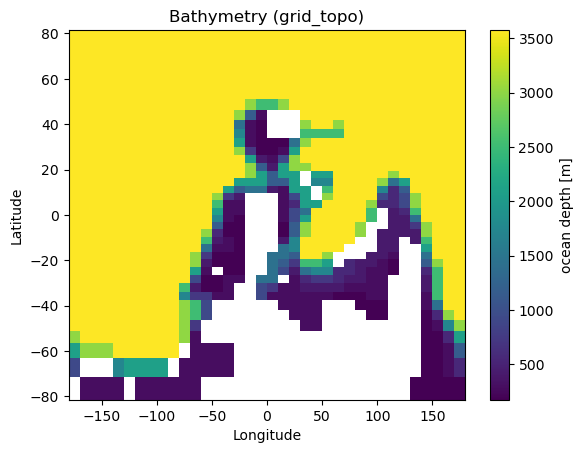

In [40]:
# === Basic Plotting of 2D Fields ===

# Plot bathymetry
data_2d['grid_topo'].plot()
plt.title("Bathymetry (grid_topo)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Example: Plot sea surface temperature at final time slice (if multiple time steps exist) from dataset_path2
# 
# data_2d['ocn_sur_temp'][9].plot() # to plot the final timeslice (of 10), because python counts from 0
# plt.title("Surface Ocean Temperature (Final Time Slice)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.show()

#### Define plotting variables 

 Assign netcdf variables a name to make easier to call later


In [25]:
#Define some variables you intend to plot, examples below

#SST = data_2d['ocn_sur_temp'][9] #if you have multiple time slices, index the time slice you want here. this is the 10th because python counts from zero
bathymetry = data_2d['grid_topo'] # otherwise if you save at only the final time slice no need for indexing
I_Ca = data_2d['proxy_sur_ICa']
ben_O2 = data_2d['ocn_ben_O2']
#sea_ice = data_2d['phys_seaice']

bathymetry

<xarray.DataArray 'grid_topo' (lat: 36, lon: 36)>
[1296 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 -175.0 -165.0 -155.0 -145.0 ... 155.0 165.0 175.0
  * lat      (lat) float64 -76.46 -66.44 -59.44 -53.66 ... 59.44 66.44 76.46
Attributes:
    valid_range:  [     0. 100000.]
    long_name:    ocean depth
    units:        m


### 3D Field Data import
 Import a single netcdf (fields_biogem_3d) file to visualize the map view of one simulation at **different vertical levels** of the ocean


In [11]:
# === Basic Plotting of 3D Fields ===

#import 3d fields data

data_3d = xr.open_dataset('genie-output/fields_biogem_3d.nc')
#data_3d = xr.open_dataset("D:/pCO2x1_PO4x1_pO2x1a/biogem/fields_biogem_3d.nc")

data_3d

<xarray.Dataset>
Dimensions:                   (time: 1, lon: 36, lat: 36, zt: 16, xu: 36,
                               yu: 36, lon_edges: 37, lat_edges: 37,
                               zt_edges: 17, xu_edges: 37, yu_edges: 37)
Coordinates:
  * time                      (time) float64 3e+03
  * lon                       (lon) float64 -175.0 -165.0 -155.0 ... 165.0 175.0
  * lat                       (lat) float64 -76.46 -66.44 -59.44 ... 66.44 76.46
  * zt                        (zt) float64 40.42 127.6 ... 3.894e+03 4.604e+03
  * xu                        (xu) float64 -180.0 -170.0 -160.0 ... 160.0 170.0
  * yu                        (yu) float64 -90.0 -70.81 -62.73 ... 62.73 70.81
  * lon_edges                 (lon_edges) float64 -180.0 -170.0 ... 170.0 180.0
  * lat_edges                 (lat_edges) float64 -90.0 -70.81 ... 70.81 90.0
  * zt_edges                  (zt_edges) float64 0.0 80.84 ... 4.235e+03 5e+03
  * xu_edges                  (xu_edges) float64 -175.0 -165.0 ... 175.0 185.0
  * yu_edges                  (yu_edges) float64 -76.46 -66.44 ... 76.46 95.65
Data variables: (12/79)
    year                      (time) float32 ...
    grid_level                (lat, lon) float64 ...
    grid_mask                 (lat, lon) float32 ...
    grid_topo                 (lat, lon) float32 ...
    grid_area                 (lat, lon) float32 ...
    grid_mask_3d              (zt, lat, lon) float32 ...
    ...                        ...
    grid_A                    (time, zt, lat, lon) float32 ...
    grid_dD                   (time, zt, lat, lon) float32 ...
    carb_d13C_CO2             (time, zt, lat, lon) float32 ...
    carb_d13C_HCO3            (time, zt, lat, lon) float32 ...
    carb_d13C_CO32            (time, zt, lat, lon) float32 ...
    misc_proxy_d13C_LA1       (time, zt, lat, lon) float32 ...
Attributes:
    Conventions:      CF-1.0
    file_name:        ./biogem/fields_biogem_3d.nc
    title:            Time averaged integrals
    experiment_name:  
    time_unit:        Year mid-point

---
To either plot **meridional** or **zonal** vertical profile at a specific lat or lon *or* to plot the **map view of a specific depth** you need to subset the data_3d xarray as below.

Ocean depth ranges from 1 to 16 where 1 is the shallowest. These are the corresponding depths.  
<div>
<img src="images/depths.jpg" width="500"/>
</div>

In [14]:
# Index vertical profile of 3D fields data

# Select the tracer variable of interest (e.g., O2, age, etc.)
# tracer_3d = data_3d['misc_col_Dage']  # Example: use age tracer
tracer_3d = data_3d['ocn_O2']        ❗  # Current selection: dissolved oxygen

# If your dataset contains only one time slice (e.g., saved at the end),
# remove the time dimension by averaging across it
tracer_3d = tracer_3d.mean(dim='time')

# Extract a horizontal map at a specific depth layer
# Syntax: tracer_3d[layer_index, lat, lon]
# Layer index ranges from 1 (shallowest) to 16 (deepest)
tracer_3d_map = tracer_3d[1, 2:, :]   ❗ # Adjust the index as needed

# Extract a vertical section (e.g., meridional or zonal slice)
# Syntax: tracer_3d[depth, lat, lon] 
tracer_3d_vert = tracer_3d[:, :, 14]  ❗ # Example: meridional section at longitude index 14

# If your dataset has multiple time slices, comment out the `.mean(dim='time')` line above
# and instead select a specific time index like this:
# tracer_3d_vert = tracer_3d[9, :, :, 14]  # Syntax: [time, depth, lat, lon]


<xarray.DataArray 'ocn_O2' (zt: 16, lat: 36, lon: 36)>
array([[[          nan, 3.2092864e-04, 3.1746810e-04, ...,
         2.8957805e-04, 2.8342716e-04, 2.7490943e-04],
        [2.7340715e-04,           nan,           nan, ...,
         2.7735176e-04, 2.7451725e-04, 2.7526301e-04],
        [2.4897183e-04, 2.4920778e-04, 2.5529132e-04, ...,
         2.4559855e-04, 2.4337199e-04, 2.4821423e-04],
        ...,
        [2.5061239e-04, 2.5038782e-04, 2.5055645e-04, ...,
         2.5138041e-04, 2.5120343e-04, 2.5078055e-04],
        [2.6016982e-04, 2.5914877e-04, 2.5841122e-04, ...,
         2.6355733e-04, 2.6250878e-04, 2.6139445e-04],
        [2.4930222e-04, 2.4832293e-04, 2.4771382e-04, ...,
         2.5047583e-04, 2.5035784e-04, 2.4981165e-04]],

       [[          nan, 1.8874537e-04, 1.7926998e-04, ...,
         1.5772834e-05, 1.1971845e-05, 4.6455634e-06],
        [5.5390046e-05,           nan,           nan, ...,
         3.6310794e-05, 7.0246191e-05, 6.3494866e-05],
        [1.5972456


# Proxy Data Upload


You can either manually select points from the grid and save it into an object or you can upload a file containing the data.

cGenie 36 x 36 grid ([chapter 3 muffin manual](https://www.seao2.info/cgenie/docs/muffin.pdf)) to help you decide what lat or lon selection you want. The numbers in the grid cells are the depth at that location (zt) in this configuration.

<div>
<img src="images/cgenie36x36grid.png" width="500"/>
</div>

It is important to remember that python counts from 0. So the indexes range from 0 to 35 not 1 to 36

## Manual Site Selection

In [18]:
# manual site selection 

lat = data_2d['lat'][35].item() # 76.46 deg
long = data_2d['lon'][23].item() # 55.0 deg

print(lat, long)

#assign a 
value = data_2d['ocn_sur_temp'].isel(lat=35, lon=23).item()
print(type(value))

site_name = "site 1"

arr = np.array([lat,long,value, site_name], dtype=object) # object forces each element to retain its orignal class
print(arr)

76.46379726261885 55.0
<class 'float'>
[76.46379726261885 55.0 8.366320610046387 'site 1']


Simple overlay of your manual point.

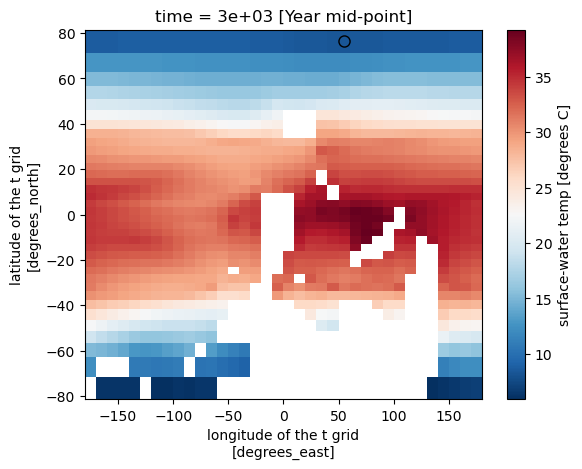

In [119]:
#plot simple overlay

data_2d['ocn_sur_temp'].plot(cmap="RdBu_r") #plot bathymetry

plt.plot(long, lat, marker='o', color='black', markerfacecolor='none', markersize=8,
         label=f"{site_name}: {value:.2f}")


Overlay multiple sites from csv file. The directory provides example csv files for background and event state proxy and SST data. 

## Import from file

In [19]:
# import proxy or location data from file
sites_df = pd.read_csv('data_files/sites_ICa_Bkgd_mod.txt', sep='\t')

sites_df['label'] = sites_df['label'].astype(str) 
sites_label =sites_df['label'] # save labels to use as overlay for figures

sites = sites_df.to_numpy()

print(f"Background proxy data is \n {sites}")


sites_df_KW = pd.read_csv('data_files/sites_ICa_KW_mod.txt', sep='\t')

sites_df_KW['label'] = sites_df_KW['label'].astype(str) 


sites_KW = sites_df_KW.to_numpy()


#print(sites_KW)
#if you have more than one set of sites for different types of measurements or values copy and paste with differen variable names as I did below

df_SST = pd.read_csv('data_files/SST_sites.txt', sep='\t')
sites_SST_label = df_SST['label']

sites_SST = df_SST.to_numpy()

print(f"Background SST data is \n {sites_SST}")



Background proxy data is 
 [[-55.1 -18.16 1.02 'DG']
 [-36.6 -27.68 2.25 'BQ']
 [6.85 -17.61 2.97 'SS']
 [104.29 -0.53 3.26 'FH']]
Background SST data is 
 [[20.6 -28.5 35.5 'F']
 [7.31 -18.9 32.4 'G']
 [99.0 1.0 32.7 'C']]


Print out details about the spatial relationship of the data to the model grid. Because cGENIE is 36x36 the nearest grid point is likely not the same as the actual paleocoordinate. If grid topography at your site is nan it is plotting over a landmass and will not be included in data-model comparison and you will want to manually move it (see below). As demonstrated in this cell.

### Adjust if necessary

In [21]:
# test for proper placement of locality data

site_coords = np.delete(sites, [2, 3], axis=1)

# Make an empty array to store the nearest model grid point coordinates
nearest_grid_point_array = np.zeros((len(site_coords), 2))

def site_details(site_coords):  # Ensure the function takes site_coords correctly
    for i, site in enumerate(site_coords):  # Correctly loop through the site coordinates
        lon, lat = site  # Unpack longitude and latitude

        # Find the nearest grid point
        nearest_grid_point = data_2d.sel(lat=lat, lon=lon, method='nearest')
        
        # Store the nearest grid point coordinates in the array
        nearest_grid_point_array[i, 0] = nearest_grid_point.lon.values
        nearest_grid_point_array[i, 1] = nearest_grid_point.lat.values
        
        # Extract grid topography at the site
        grid_topo_at_site = nearest_grid_point.grid_topo.values

        print(f"Grid topography at site ({lon}, {lat}): {grid_topo_at_site}")

# Call the function correctly
site_details(site_coords)


Grid topography at site (-55.1, -18.16): 728.831298828125
Grid topography at site (-36.6, -27.68): 283.8467102050781
Grid topography at site (6.85, -17.61): 1426.4306640625
Grid topography at site (104.29, -0.53): nan


We can see that the FH point is plotting over the landmass resulting in a nan. To move this point we can either change the data file and rerun everything or we can modify it here because we saved it as an array. We want to move it over to the left side of the landmass.

In [33]:
# move location of sites, if necessary

# Modify values in 'sites' before deleting columns
sites[3, 0] = 99 # Change first column of row 3
sites_KW[3, 0] = 99  # Assuming this dataset should match sites

#sites[0, 1] = -15.5  # Change second column of row 0
#sites_KW[0, 1] = -15.5

print(sites)  # Check modifications

# Drop columns 2 and 3
site_coords = np.delete(sites, [2, 3], axis=1)

# Create an empty array for nearest grid points
nearest_grid_point_array = np.zeros((len(site_coords), 2))

# Call the function with the modified dataset
site_details(site_coords)


#np.savetxt("sites_kw_adjusted.csv", sites_KW, delimiter=",", fmt="%s")

[[-55.1 -18.16 1.02 'DG']
 [-36.6 -27.68 2.25 'BQ']
 [6.85 -17.61 2.97 'SS']
 [99 -0.53 3.26 'FH']]
Grid topography at site (-55.1, -18.16): 728.831298828125
Grid topography at site (-36.6, -27.68): 283.8467102050781
Grid topography at site (6.85, -17.61): 1426.4306640625
Grid topography at site (99, -0.53): 2520.052734375


You will be using the modified site_coords array to plot data in mapview

Here I have a collection of proxy data and want the sites to be colored according to a value in another column in the file. I want black to equate to 'anoxia', grey to 'hypoxia', and white to 'oxic'. I also want different shapes for bottom and surface water proxies. 

## Import Large Observation dataset

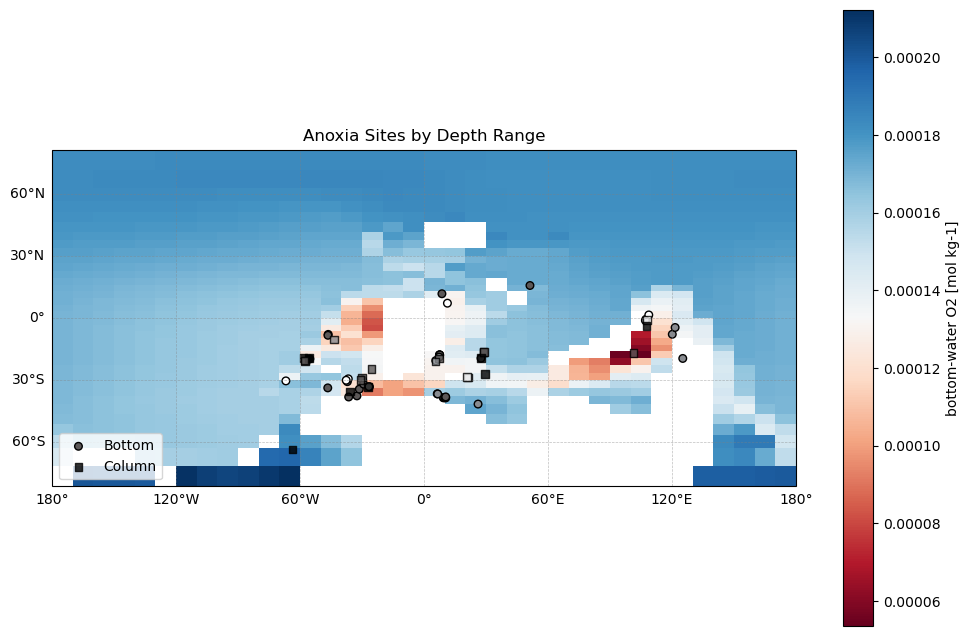

In [177]:
# Load and clean data
df_bottom = pd.read_csv('FF sites.csv', encoding='unicode_escape')
df_bottom = df_bottom[df_bottom['Depth range of anoxia'] == "bottom"].copy()

df_column = pd.read_csv('FF sites.csv', encoding='unicode_escape')
df_column = df_column[df_column['Depth range of anoxia'] != "bottom"].copy()

# Replace NaNs with 0 in coordinate columns
for df in [df_bottom, df_column]:
    df['UKW (370 Ma) Paleocoord (Long)'] = df['UKW (370 Ma) Paleocoord (Long)'].fillna(0)
    df['UKW (370 Ma) Paleocoord (LAT)'] = df['UKW (370 Ma) Paleocoord (LAT)'].fillna(0)

# Coordinates
lon_b = df_bottom['UKW (370 Ma) Paleocoord (Long)']
lat_b = df_bottom['UKW (370 Ma) Paleocoord (LAT)']
color_b = df_bottom['Color'].astype(str)

lon_c = df_column['UKW (370 Ma) Paleocoord (Long)']
lat_c = df_column['UKW (370 Ma) Paleocoord (LAT)']
color_c = df_column['Color'].astype(str)

# Plot
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and grid

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False


ben_O2.plot(cmap="RdBu")

# Plot bottom sites as circles
points = ax.scatter(lon_b, lat_b, transform=ccrs.PlateCarree(), marker='o',
                    color=color_b, s=30, edgecolor='black', label='Bottom')

# Plot column sites as squares
points_col = ax.scatter(lon_c, lat_c, transform=ccrs.PlateCarree(), marker='s',
                        color=color_c, s=30, alpha=0.8, edgecolor='black', label='Column')


# Legend
plt.legend(loc='upper left')
plt.title('Anoxia Sites by Depth Range')
plt.show()



# Ploting 2-d fields 

### Mapviews (surface or benthic features)

<a name="cell-2dmap"></a>Plot 2d map view of 2d field saved in data_2d xarray, below is an example. If you want to plot something else use the
[Guide to Colomaps](https://matplotlib.org/stable/gallery/color/colormap_reference.html) to pick an appopriate colormap. Follow the comments to change each line accordingly.

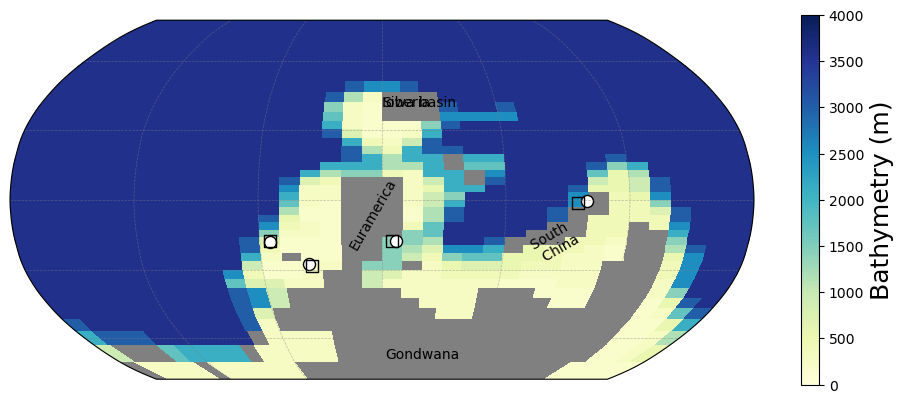

In [35]:
#2d field map of surface, benthic or specific ocean layer

#define colormap,
cmap = plt.get_cmap('YlGnBu') #use for bathymetry
#cmap = plt.get_cmap('RdYlBu_r') #use for SST
#cmap.set_over('#751a06') #use for SST
#cmap = plt.get_cmap('viridis') #for surface proxies
#cmap = plt.get_cmap('RdBu_r') #dissolved O2

#-------------------------------------------------------#
#Define plotting area and variable to plot
subplot_kws=dict(projection=ccrs.Robinson(),
                 facecolor='grey')

plt.figure(figsize=[12,8]) # change size of figure


p = bathymetry.plot(x='lon', y='lat', #change variable whatever you defined above, if want to plot certain level in ocean plot tracer3d
                  vmin=0, vmax = 4000, #change min and max if desired
                  cmap=cmap,#change color map depending on variable
                  subplot_kws=subplot_kws,
                  transform=ccrs.PlateCarree(),
                  add_labels=False,
                  add_colorbar=False)

#------------------------------------------------------------#
#aspects of color bar depending on what you are plotting #change ticks if  you want different increments,
cb = plt.colorbar(p, ticks=[0, 500,  1000, 1500,  2000, 2500, 3000, 3500, 4000] , shrink=0.6)  #bathymetry
#cb = plt.colorbar(p, ticks=[0,4,8,12,16,20,24,28,32,36, 40], shrink=0.6) #change to this if you want SST
#cb = plt.colorbar(p, ticks=[0,1,2,3,4], shrink=0.6)
    #cb = plt.colorbar(p, ticks=[0,.0001,.0002,.0003], shrink=0.6)


cb.set_label('Bathymetry (m)', fontsize=18) #colorbar title 
#cb.set_label(r'SST (°C)', fontsize=18)
#cb.set_label(r'I/Ca $\mu$mol/mol', fontsize=18)


#cb.ax.tick_params(labelsize=18)
#-------------------------------------------------------#

#overlay the sites, comment out if don't want site overlay,  c=sites[:,2], vmin=0, vmax=4, cmap=fmap, if you want to color the symbols by value
p.axes.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

#simplest plotting, as shape with solid color
#plt.scatter(x = site_coords[:,0], y = site_coords[:,1], edgecolor = 'black', c = 'white', marker = 'o', transform=ccrs.PlateCarree(), s = 250) 

# plot nearest grid point and uncorrected site locations to show offset
plt.scatter(x = sites[:,0], y = sites[:,1], edgecolor = 'black', c = 'white', marker = 'o', transform=ccrs.PlateCarree(), s = 75) 

plt.scatter(x = nearest_grid_point_array[:,0], y = nearest_grid_point_array[:,1], facecolors='none', edgecolor = 'black', marker = 's', transform=ccrs.PlateCarree(), s = 75) #plots the center of the nearest grid point that will be used for data comparison

#Plot points colored by value
#plt.scatter(x = site_coords[:,0], y = site_coords[:,1], c = sites[:,2], cmap = cmap, vmin=0, vmax=4, edgecolor = 'black', marker = 'o', transform=ccrs.PlateCarree(), s = 75) 

#------------------------------------------------------#

#print labels for sites
#for i, txt in enumerate(sites_label):#if it prints too close then change sites[i,0] to whatever coordinate
 #   plt.annotate(txt, (site_coords[i,0], site_coords[i,1]), fontsize = 9, transform=ccrs.PlateCarree(),textcoords="offset points", xytext=(0,0), ha = "center", va = "center", fontweight = 'bold',color = 'black')

#for i, txt in enumerate(sites_SST_label):
 #   plt.annotate(txt, (sites_SST[i,0], sites_SST[i,1]), fontsize = 10, transform=ccrs.PlateCarree(), textcoords="offset points", xytext=(-10,-10), ha='center', fontweight = 'bold', color = 'black')



plt.annotate("Gondwana", (2, -70), fontsize = 10, transform=ccrs.PlateCarree())

plt.annotate("Euramerica", (-17, -21), fontsize = 10, transform=ccrs.PlateCarree(), rotation = 60)

plt.annotate("South \n China", (73, -27),fontsize = 10, transform=ccrs.PlateCarree(), rotation=30)

plt.annotate("Siberia", (0, 40),fontsize = 10, transform=ccrs.PlateCarree())

plt.annotate("Iowa basin", (0, 40),fontsize = 10, transform=ccrs.PlateCarree())

#plt.legend(['I/Ca'])
#plt.legend(['I/Ca', 'Nearest grid point']) #if plotting mutliple type of points
#plt.title('M-score: 0.01')

#----------------------------------------------# 
# remember to deselect this after saving
#plt.savefig('Figures/bathymetry_presentation.png', dpi=300, bbox_inches='tight')

plt.show()



### Contour maps
of circulation features (e.g. overturning streamfunctions)

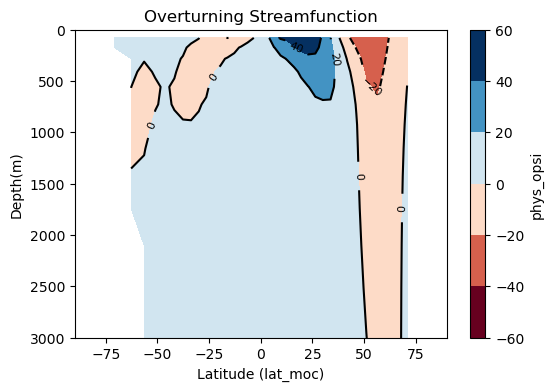

In [90]:
#data_2d["phys_opsi"].plot(yincrease=False) # default plotting
#plt.ylim(3000,0)

#make it pretty 
f = data_2d["phys_opsi"].mean(dim="time") # this is defined separaetly because it is technically 2d

fig, ax = plt.subplots(figsize=(6, 4))

cmap = plt.get_cmap("RdBu").copy()
#not sure why set_bad is not working 

# filled contours (with colors)
cf = f.plot.contourf(ax=ax, yincrease=False, cmap=cmap, add_colorbar=True)

# Plot overlayed contour lines
cs = f.plot.contour(ax=ax, yincrease=False, colors="black")
ax.clabel(cs, inline=True, fontsize=8)

ax.set_xlabel("Latitude (lat_moc)")
ax.set_ylabel("Depth(m)")
ax.set_title("Overturning Streamfunction")
ax.set_ylim(3000, 0) # Reverse y-axis (again)


#plt.savefig('Figures/Scotese370Ma_opsi_narrowgateway.png', dpi=300, bbox_inches='tight')

plt.show()



### Plot Wind Fields 

To plot wind fields you need the wind stress in N m-2 and convert to velocity to scale the vectors.

In [92]:
# assign u and v stress components from 2D fields 

u_stress = data_2d['phys_tau_u'].isel(time = 0) # remove the time component
v_stress = data_2d['phys_tau_v'].isel(time = 0)

lons = data_2d['lon']
lats = data_2d['lat']

print(u_stress)
print(lons)

<xarray.DataArray 'phys_tau_u' (lat: 36, lon: 36)>
[1296 values with dtype=float32]
Coordinates:
    time     float64 1e+04
  * lon      (lon) float64 -175.0 -165.0 -155.0 -145.0 ... 155.0 165.0 175.0
  * lat      (lat) float64 -76.46 -66.44 -59.44 -53.66 ... 59.44 66.44 76.46
Attributes:
    long_name:  wind stress (u)
    units:      N/m-2
<xarray.DataArray 'lon' (lon: 36)>
array([-175., -165., -155., -145., -135., -125., -115., -105.,  -95.,  -85.,
        -75.,  -65.,  -55.,  -45.,  -35.,  -25.,  -15.,   -5.,    5.,   15.,
         25.,   35.,   45.,   55.,   65.,   75.,   85.,   95.,  105.,  115.,
        125.,  135.,  145.,  155.,  165.,  175.])
Coordinates:
  * lon      (lon) float64 -175.0 -165.0 -155.0 -145.0 ... 155.0 165.0 175.0
Attributes:
    axis:           X
    edges:          lon_edges
    long_name:      longitude of the t grid
    standard_name:  longitude
    units:          degrees_east


In [94]:
# convert to wind speed or don't it is not necessary it only changes to units
rho_air = 1.22  # kg/m³
Cd = 1.3e-3     # drag coefficient

u_wind = np.sign(u_stress) * np.sqrt(np.abs(u_stress) / (rho_air * Cd))
v_wind = np.sign(v_stress) * np.sqrt(np.abs(v_stress) / (rho_air * Cd))


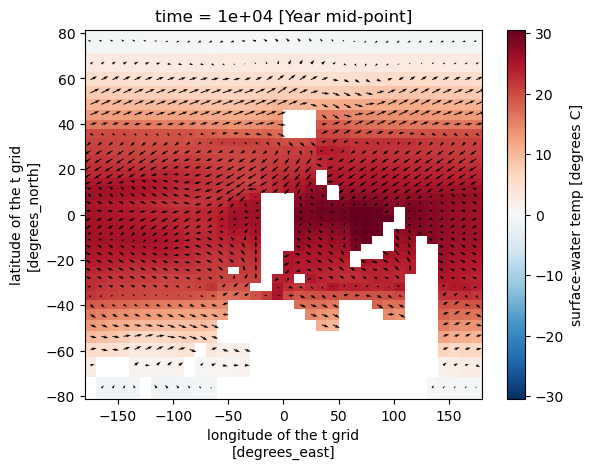

In [96]:
# use plt.quiver to plot vectors scaled by magnitude

lon2d, lat2d = np.meshgrid(lons, lats) # this takes the 1D arrays and makes a grid out of them to plot the stress fields on 

data_2d['ocn_sur_temp'].plot()
plt.quiver(         #takes [x,y,u,v] # if you want to plot wind speed 

    lons,
    lats,
    u_wind,
    v_wind,    
)

plt.show()

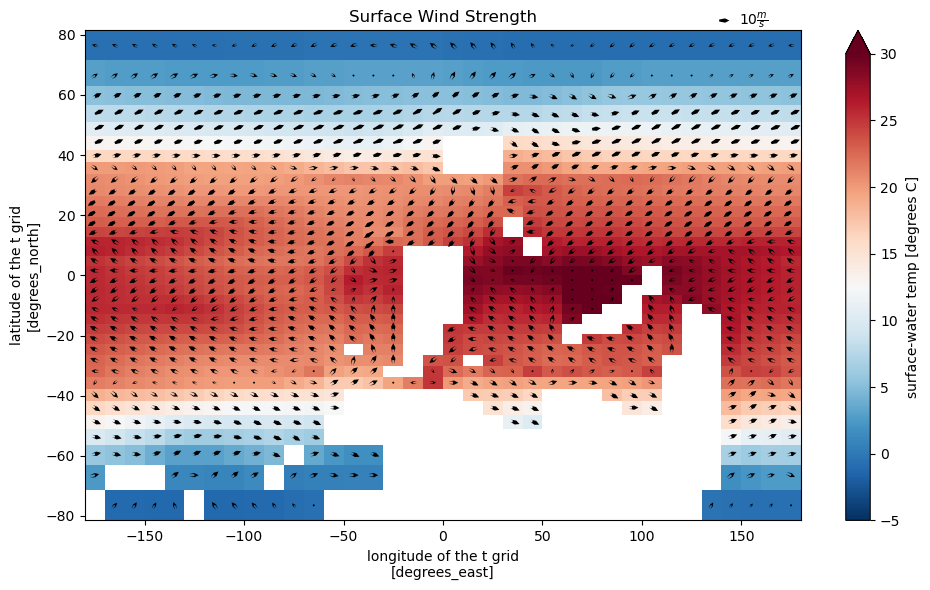

In [100]:
lon2d, lat2d = np.meshgrid(lons, lats)

# Create the figure and axes
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Plot scalar field (tell xarray to use existing ax)
data_2d['ocn_sur_temp'].plot(ax=ax1, 
                             cmap='RdBu_r',
                            vmin=-5, vmax=30)

# Overlay wind vectors
Q = ax1.quiver(
    lon2d,
    lat2d,
    u_wind,
    v_wind,
    units='width',
    scale=700,            # adjust to match your data
    width=0.003,
    headwidth = 2,
    headlength=2,
    color='k'             # black arrows for contrast
)

# Add quiver key
ax1.quiverkey(
    Q, 0.9, 1.02, 10, r'$10 \frac{m}{s}$', labelpos='E',
    coordinates='axes'
)

# Set title and show plot
ax1.set_title("Surface Wind Strength")
plt.tight_layout()

@plt.savefig('Figures/Scotese370Ma_windstrength_narrowgateway.png', dpi=300, bbox_inches='tight')

plt.show()


### Latitudinal Gradients 
(e.g. SST or sea ice extent)


In [8]:
sites_SST[:,1]

C:\Users\prowa\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
C:\Users\prowa\anaconda3\Lib\ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
C:\Users\prowa\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
C:\Users\prowa\anaconda3\Lib\ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)


NameError: name 'sites_SST' is not defined

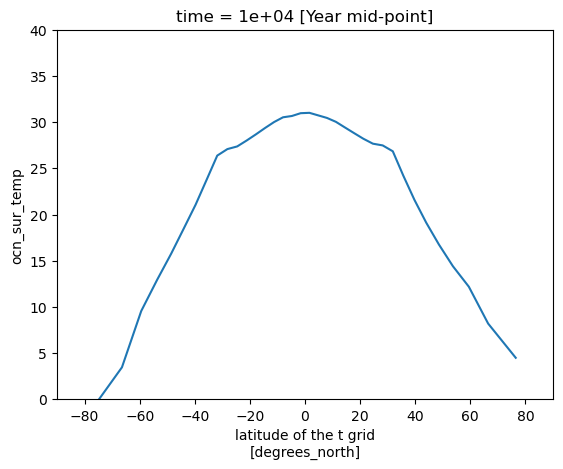

In [36]:
#plot zonal gradient of surface tracer


#SST_timeavg = SST.mean(dim='time') #this reduces itto a 2D xarray 
#print(SST_timeavg)

#SST_timeavg.plot.line(x= 'lat')  #plot SST along all longitude

#subset just the latitude 

#zonal_SST = SST_timeavg[:,16]#SST[lat,lon]; for a latitudinal gradient at one long 18 is about half way 
zonal_SST = SST.mean(dim="lon", skipna=True) #plots average zonal gradient

zonal_SST.plot.line(x= 'lat', xlim= (-90,90), ylim = (0,40)) 
#plt.scatter(x = sites_SST[:,1] , y =sites_SST[:,2]) #add data sites, or don't 


In [22]:
def unpak_single_tar(path, to_folder="temp"):
    """
    Open cGENIE biogem outputs from either:
      - A .tar/.tar.gz archive
      - An already-extracted folder
    Returns:
      data_2d, data_3d, path_2d, path_3d
    """
    path = Path(path)

    # Case 1: it's a tarball
    if path.is_file() and tarfile.is_tarfile(path):
        parent_dir = path.parent
        with tarfile.open(path, "r:*") as tar:
            tar.extractall(path=parent_dir)
        # after extraction, use tar's stem as folder name
        base_name = path.name
        for suffix in [".tar.gz", ".tar.bz2", ".tar.xz", ".tar"]:
            if base_name.endswith(suffix):
                base_name = base_name[: -len(suffix)]
                break
        extract_dir = parent_dir / base_name

    # Case 2: it's already an extracted folder
    elif path.is_dir():
        extract_dir = path

    else:
        raise ValueError(f"Path {path} is neither a tar archive nor a directory.")

    # Search inside for files
    found_2d, found_3d = None, None
    for root, dirs, files in os.walk(extract_dir):
        if "fields_biogem_2d.nc" in files:
            found_2d = Path(root) / "fields_biogem_2d.nc"
        if "fields_biogem_3d.nc" in files:
            found_3d = Path(root) / "fields_biogem_3d.nc"
        if found_2d and found_3d:
            break

    if not found_2d or not found_3d:
        raise FileNotFoundError("Could not locate fields_biogem_2d.nc or fields_biogem_3d.nc")

    return xr.open_dataset(found_2d), xr.open_dataset(found_3d), str(found_2d), str(found_3d)

In [26]:
bkg_2d, bkg_3d, bkg_2d_path, bkg_3d_path = unpak_single_tar(dataset_path)
kw_2d, kw_3d, kw_2d_path, kw_3d_path = unpak_single_tar(dataset_path)

bkg_sst = bkg_2d['ocn_sur_temp']
bkg_sst_lat = bkg_sst.mean(dim="lon", skipna=True)

kw_sst = kw_2d['ocn_sur_temp']
kw_sst_lat = kw_sst.mean(dim="lon", skipna=True)

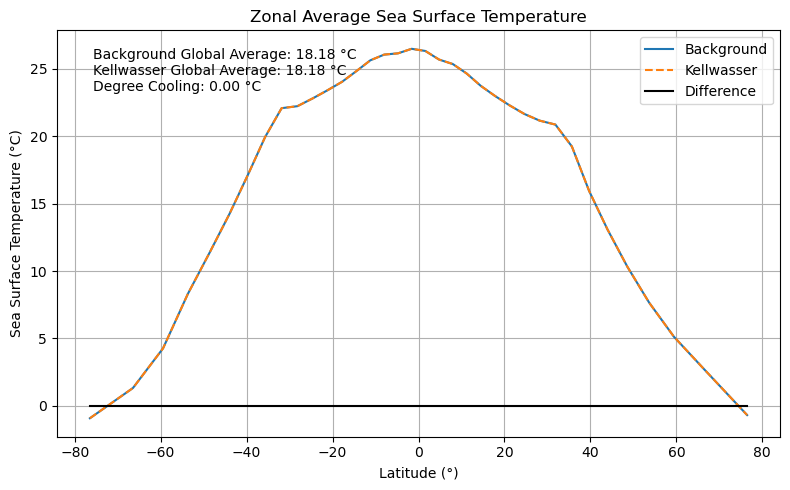

In [28]:

# --- Final timestep ---
bkg_sst = bkg_2d['ocn_sur_temp'].isel(time=-1)
kw_sst  = kw_2d['ocn_sur_temp'].isel(time=-1)

# --- Zonal (longitude) means ---
bkg_sst_lat = bkg_sst.mean(dim="lon", skipna=True)
kw_sst_lat  = kw_sst.mean(dim="lon", skipna=True)

bkg_mean = bkg_sst.mean(dim=("lat","lon"), skipna=True).item()
kw_mean  = kw_sst.mean(dim=("lat","lon"), skipna=True).item()
change   = bkg_mean - kw_mean

# --- Difference of zonal means ---
lat_diff = bkg_sst_lat - kw_sst_lat

# --- Plot ---
plt.figure(figsize=(8,5))
bkg_sst_lat.plot.line(x='lat', label="Background")
kw_sst_lat.plot.line(x='lat', linestyle='--', label="Kellwasser")
lat_diff.plot.line(x='lat', color="k", label="Difference")

plt.text(
    0.05, 0.85, 
    f"Background Global Average: {bkg_mean:.2f} °C\n"
    f"Kellwasser Global Average: {kw_mean:.2f} °C\n"
    f"Degree Cooling: {change:.2f} °C", 
    transform=plt.gca().transAxes
)

plt.xlabel("Latitude (°)")
plt.ylabel("Sea Surface Temperature (°C)")
plt.title("Zonal Average Sea Surface Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(path_to_figs +"/Transitions/Transition 16/lat_sst.png")
plt.show()



## Plotting 3d field data


With 3d field data you can plot map view of a certain depth in ocean (z_t), meridional and zonal profiles, and linear profiles at a specific siteb

### Map view of specific ocean layer

NameError: name 'tracer_3d_map' is not defined

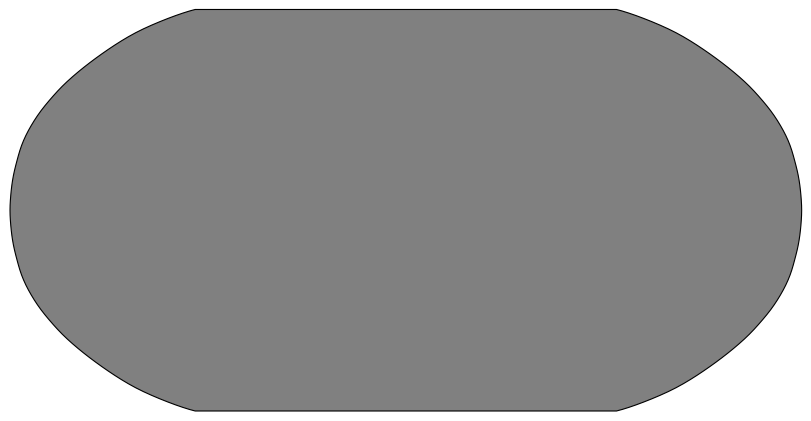

In [165]:
# Subplot settings
subplot_kws = dict(projection=ccrs.Robinson(), facecolor='grey')

# Create a single subplot
fig, ax = plt.subplots(figsize=(8, 6), layout = "constrained", subplot_kw=subplot_kws)

# Plot data on the map
p = tracer_3d_map.plot(
    x='lon', y='lat',
    vmin=0,
    #vmax = 0.00008,
    vmax = 200, #you can either set this value to what you want 
    #vmax = np.nanmax(tracer_3d), # this makes the highest colorbar value the largest value 
    cmap='viridis_r', #change to whatever color 
    ax=ax,
    transform=ccrs.PlateCarree(),
    add_labels=False,
    add_colorbar=False
)
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--') #comment out if you don't want coordinates andgridlines
# Add a colorbar
# cb = plt.colorbar(
    # p, ticks=[0, 0.00001, 0.00002, 0.00003, 0.00004, 0.00005, 0.00006, 0.00007],
     # extend="max", format='%.2e', orientation='horizontal'
# )
#plt.colorbar(p, format=ticker.FuncFormatter(fmt))
cbar = plt.colorbar(p, orientation='vertical', extend="max", shrink = 0.6)
cbar.formatter.set_powerlimits((0, 0))

# to get 10^3 instead of 1e3
cbar.formatter.set_useMathText(True)

cbar.ax.tick_params(labelsize=18)
cbar.set_label('Ventilation age (yrs)', fontsize=18)

# Set subplot title
#ax.set_title('$O_2$ (~80-125m depth)', fontsize=20)

#plt.savefig('subsurface_O2_bkg.png', dpi=300, bbox_inches='tight')


plt.show()




### Zonal and meridional profiles
of tracer_3d

Text(0.5, 0, 'Latitude')

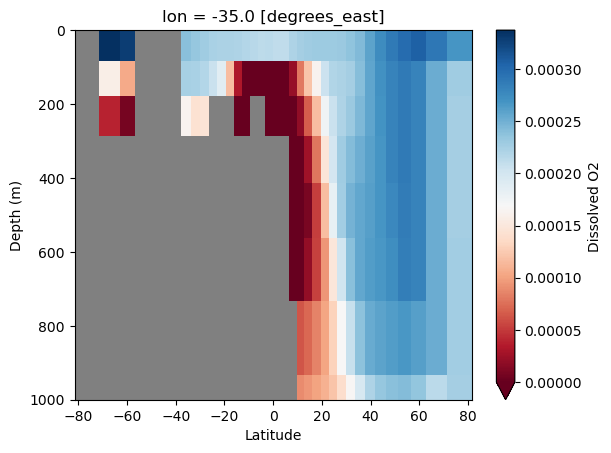

In [21]:
#make sure tracer_3d is saved as tracer_3d = tracer_3d[:,:,#], this plots specific longitude

cmap = plt.get_cmap("RdBu")  
cmap.set_bad("gray") # makes landmass grey
#tracer_3d_vert = tracer_3d.mean(dim = 'lon', skipna =True) #average over all lon

tracer_3d_vert.plot(yincrease =False, #reversed the axis 
               cmap = cmap, 
               vmin = 0 , 
               #vmax = 0.00015,
              cbar_kwargs={"label": "Dissolved O2"}) # be sure to change tracer_3d to the tracer you want and the lat or long you want
plt.ylabel("Depth (m)")
plt.ylim(1000,0) # deeper value first because axis is reversed

plt.xlabel("Latitude")

In [37]:
#this block could be improved by making it for x number of sites 

vert_data = data_3d['ocn_O2'] #save into new variable 

# save just the data for the nearest grid point at each site 
profile = vert_data.sel(lon=sites[:,0],lat=sites[:,1],method="nearest") # select your site
#print(profile)

#obviosuly change the site names to your sites 
DG = profile[0, :,0,0]
BQ = profile[0, :,1,1]
SS = profile[0, :,2,2]
FH = profile[0, :,3,3] # (time: 1, zt: 16, lat: 4, lon: 4) This selects the vertical profile at site 4 bc python likes to count from 0 


depthvar = data_2d['zt']
depthvals = depthvar[:]
plt.xlabel(FH.long_name   + ' (' + FH.units   + ')') #you just need the xlabel from one of the sites
plt.ylabel(depthvar.long_name + ' (' + depthvar.units + ')')
plt.ylim(0,2000)
plt.gca().invert_yaxis()
plt.plot(FH, depthvals, label = "FH", color ='blue') #could be improved with different line types
plt.plot(BQ, depthvals, label = "BQ", color ='red')
plt.plot(DG, depthvals, label = "DG", color ='orange')
plt.plot(SS, depthvals, label = "SS", color ='green')
plt.legend(loc='lower left')
plt.title('Vertical profile')
plt.show()


NameError: name 'data_3d' is not defined

### Difference plots 

Plot the spatial differences in tracers fields between **two different simulations** 

In [327]:
# import simulations to compare

# save these locally as examples

sim1 = xr.open_dataset("D:/250107b/250107.pO2xPO4_5x5b.dat.33/biogem/fields_biogem_3d.nc") # background 
sim2 = xr.open_dataset("D:/250210b/250210.pO2xPO4_5x5b.dat.14/biogem/fields_biogem_3d.nc") # Event


In [325]:
sim1

<xarray.Dataset>
Dimensions:                    (time: 1, lon: 36, lat: 36, zt: 16, xu: 36,
                                yu: 36, lon_edges: 37, lat_edges: 37,
                                zt_edges: 17, xu_edges: 37, yu_edges: 37,
                                lat_moc: 37, zt_moc: 17, lat_moc_edges: 38,
                                zt_moc_edges: 18, lon_psi: 36, lat_psi: 37,
                                lon_psi_edges: 37, lat_psi_edges: 38)
Coordinates: (12/19)
  * time                       (time) float64 2e+03
  * lon                        (lon) float64 -175.0 -165.0 ... 165.0 175.0
  * lat                        (lat) float64 -76.46 -66.44 ... 66.44 76.46
  * zt                         (zt) float64 40.42 127.6 ... 3.894e+03 4.604e+03
  * xu                         (xu) float64 -180.0 -170.0 -160.0 ... 160.0 170.0
  * yu                         (yu) float64 -90.0 -70.81 -62.73 ... 62.73 70.81
    ...                         ...
  * lat_moc_edges              (lat_moc_edges) float64 -95.65 -76.46 ... 95.65
  * zt_moc_edges               (zt_moc_edges) float64 0.0 40.42 ... 5e+03
  * lon_psi                    (lon_psi) float64 -170.0 -160.0 ... 170.0 180.0
  * lat_psi                    (lat_psi) float64 -90.0 -70.81 ... 70.81 90.0
  * lon_psi_edges              (lon_psi_edges) float64 -175.0 -165.0 ... 185.0
  * lat_psi_edges              (lat_psi_edges) float64 -95.65 -76.46 ... 95.65
Data variables: (12/176)
    year                       (time) float32 ...
    grid_level                 (lat, lon) float64 ...
    grid_mask                  (lat, lon) float32 ...
    grid_topo                  (lat, lon) float32 ...
    grid_area                  (lat, lon) float32 ...
    atm_temp                   (time, lat, lon) float32 ...
    ...                         ...
    proxy_Dd13C                (time, lat, lon) float32 ...
    proxy_ben_DIC_d13C         (time, lat, lon) float32 ...
    proxy_ben_HCO3_d13C        (time, lat, lon) float32 ...
    proxy_ben_LA1              (time, lat, lon) float32 ...
    proxy_sur_ICa              (time, lat, lon) float32 ...
    proxy_ben_ICa              (time, lat, lon) float32 ...
Attributes:
    Conventions:      CF-1.0
    file_name:        ./biogem/fields_biogem_2d.nc
    title:            Time averaged integrals
    experiment_name:  
    time_unit:        Year mid-point

In [195]:
# define what difference you want to observe 

#for 2d, make sure use biogem.fields 2d-------------------------------------
anom =  bkg_2d['ocn_sur_temp']-kw_2d['ocn_sur_temp']

#anom = sim1['ocn_ben_O2'] - sim2['ocn_ben_O2'] #3 remember to slice it if you have multiple saves


#for 3d----------------------------

anom_3d = bkg_3d['ocn_O2'].isel(time = 0, zt = 2) - kw_3d['ocn_O2'].isel(time = 0, zt = 2)

# want difference of two levels of same sim? Just change indexing. subtract level 1 from level 2.
#anom = sim1['misc_col_Dage'][4, 0,:,:] -sim1['misc_col_Dage'][4, 1,:,:] #[time, zt, lat, lon] 

In [242]:
# difference between site values
sites_diff = sites_KW[:,2]-sites[:,2]
sites_diff # this is a 1D array

print(math.floor(max(sites_diff)))
print(math.floor(min(sites_diff)))

-1
-3


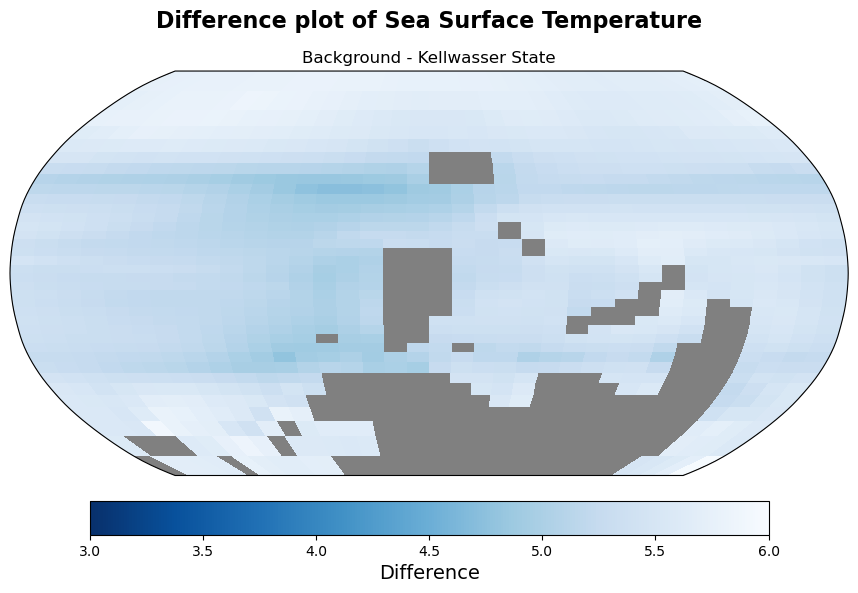

In [197]:
# some diverging color maps to choose from, all have light or white color middle

#cmap = plt.get_cmap('PuOr_r') #Or is pos, use to distinguish between temp which is usually RdBu
#cmap = plt.get_cmap('coolwarm_r')
#cmap = plt.get_cmap('PiYG')
 #cmap = plt.get_cmap('PiYGs')
cmap = plt.get_cmap('Blues_r')

#sequential colormaps for differences that are only in pos or neg directions

#cmap = plt.get_cmap('YlOrRd_r')
#cmap = plt.get_cmap('BuPu_r')
#cmap = plt.get_cmap('PuRd_r')
#cmap = plt.get_cmap('BuGn')


# Set up figure and axis with cartopy projection
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_facecolor('grey')

# Plot the xarray data onto the axis
a = anom.plot(
    ax=ax,
    x='lon', y='lat',
    vmin = 3, vmax = 6, #scale to the difference in observational values rounded up/down, comment whole line if not using points
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

# Overlay scatter plot
# sc = ax.scatter(
    # x=site_coords[:, 0], y=site_coords[:, 1],
    # c=sites_diff, cmap=cmap,
    #vmin=-3, vmax=3,
    # edgecolor='black', marker='o', s=75,
    # transform=ccrs.PlateCarree()
# )

# Add a tightly controlled horizontal colorbar
cbar = fig.colorbar(a, ax=ax, orientation='horizontal', shrink=0.7, pad=0.05)
cbar.set_label('Difference', fontsize=14)

# Titles
plt.suptitle("Difference plot of Sea Surface Temperature", y=0.98, fontsize=16, fontweight='bold')
ax.set_title("Background - Kellwasser State", fontsize=12)

plt.tight_layout()  # Helps layout elements without excessive whitespace
# plt.savefig('Figures/Transitions/Transition 16/temp_diff_plot.png', dpi=300, bbox_inches='tight')
plt.show()


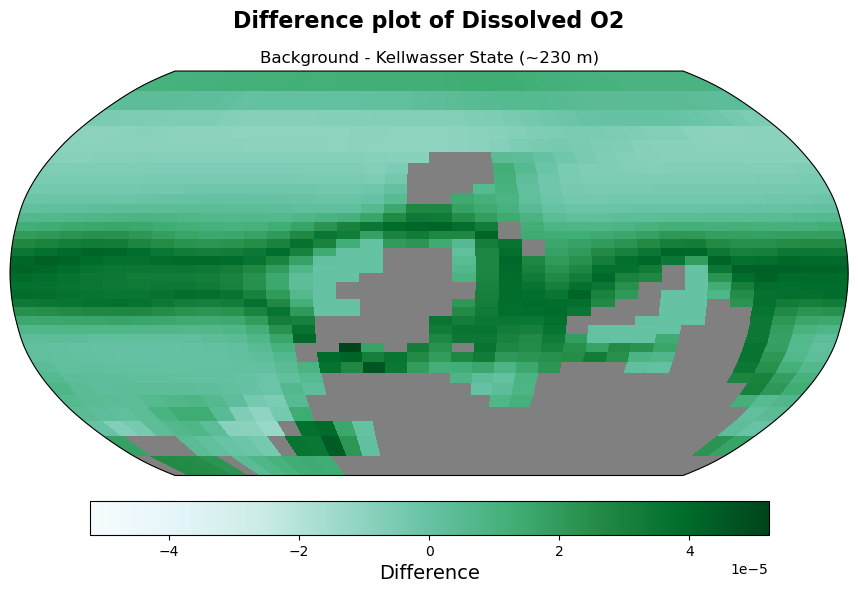

In [199]:
# some diverging color maps to choose from, all have light or white color middle

#cmap = plt.get_cmap('PuOr_r') #Or is pos, use to distinguish between temp which is usually RdBu
#cmap = plt.get_cmap('coolwarm')
#cmap = plt.get_cmap('PiYG')
# cmap = plt.get_cmap('PiYGs')


#sequential colormaps for differences that are only in pos or neg directions

#cmap = plt.get_cmap('YlOrRd_r')
#cmap = plt.get_cmap('BuPu_r')
#cmap = plt.get_cmap('PuRd_r')
cmap = plt.get_cmap('BuGn')


# Set up figure and axis with cartopy projection
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_facecolor('grey')

# Plot the xarray data onto the axis
a = anom_3d.plot(
    ax=ax,
    x='lon', y='lat',
    #vmin = -3, vmax = 3, #scale to the difference in observational values rounded up/down, comment whole line if not using points
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

# Overlay scatter plot
# sc = ax.scatter(
    # x=site_coords[:, 0], y=site_coords[:, 1],
    # c=sites_diff, cmap=cmap,
    #vmin=-3, vmax=3,
    # edgecolor='black', marker='o', s=75,
    # transform=ccrs.PlateCarree()
# )

# Add a tightly controlled horizontal colorbar
cbar = fig.colorbar(a, ax=ax, orientation='horizontal', shrink=0.7, pad=0.05)
cbar.set_label('Difference', fontsize=14)

# Titles
plt.suptitle("Difference plot of Dissolved O2", y=0.98, fontsize=16, fontweight='bold')
ax.set_title("Background - Kellwasser State (~230 m)", fontsize=12)

plt.tight_layout()  # Helps layout elements without excessive whitespace
# plt.savefig('Figures/Transitions/Transition 16/O2_diff_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## Plot time series data

Time series data exists in the biogem folder. 

     time_yr  temperature_c  surt_ice_free_c  bent_c_[>_2000_m]     surt_c
0        0.5       5.048539         7.405453           4.975242   7.405453
1        1.5       5.125145        10.555772           4.936105  10.551862
2        2.5       5.189509        12.472217           4.907054  12.444750
3        3.5       5.245798        13.742308           4.883196  13.695481
4        4.5       5.296533        14.646628           4.862369  14.586558
..       ...            ...              ...                ...        ...
285   1919.5       7.993429        24.072104           3.510502  24.072104
286   1939.5       7.994976        24.072376           3.513083  24.072376
287   1959.5       7.996502        24.072653           3.515621  24.072653
288   1979.5       7.998002        24.072918           3.518106  24.072918
289   1999.5       7.999476        24.073177           3.520532  24.073177

[290 rows x 5 columns]


C:\Users\prowa\AppData\Local\Temp\ipykernel_17376\1461890364.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  series_SST = pd.read_csv("C:/Users/prowa/Documents/Git_workspace/Output/biogem/biogem_series_ocn_temp.res", #navigate to whatever folder you want to plot,


<Axes: xlabel='time_yr', ylabel='surt_c'>

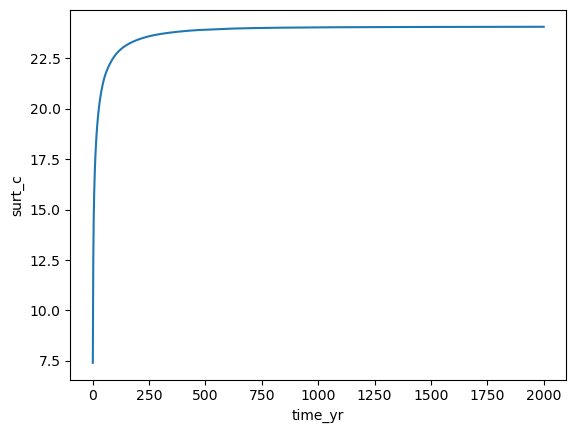

In [46]:
#import and save time series into ts_varaible, here I import global SST and save as a dataframe

column_names = ["Time (yr)", "Temperature (C)", "_surT (ice-free) (C)", "_benT (C) [> 2000 m]", "_surT (C)"]  #start by designating column names
series_SST = pd.read_csv("C:/Users/prowa/Documents/Git_workspace/Output/biogem/biogem_series_ocn_temp.res", #navigate to whatever folder you want to plot,
                         delim_whitespace=True, names=column_names, skiprows=1)                            # here I plot an example that I saved in its own folder, Output

#these column names are silly to call, use janitor to tidy them
series_SST = series_SST.clean_names(strip_underscores=True)# this removes the leading underscores and converst everything to lowercase

print(series_SST)
sns.lineplot(data = series_SST, x = "time_yr", y = "surt_c")

In [48]:
#collect the value of the final timeslice

equil_SST = series_SST.iloc[-1]["surt_c"]

print(equil_SST)

24.073177


To do this for an ensemble of runs see Ensemble section

# Ensembles

## Import ensemble data

Import the 2d and 3d fields from the folder containing the ensemble runs and save into dataframes *plot_me_2d* and *plot_me_3d*

[Link to plot](#ensemble)  


If the folder you are working with has tarted subfolders containing the output use this to extract to ""/temp" from main directory. Otherwise skip this cell and use the direct path in the next cell.

In [19]:
# 
def untar_all_to_temp(from_folder, to_folder="temp"):
    os.makedirs(to_folder, exist_ok=True)  # Create temp directory if needed

    tar_files = glob.glob(os.path.join(from_folder, "*.tar*"))  # Match .tar, .tar.gz, etc.

    for tar_path in tar_files:
        if tarfile.is_tarfile(tar_path):
            print(f"Extracting {os.path.basename(tar_path)} to {to_folder}")
            with tarfile.open(tar_path, 'r:*') as tar:
                tar.extractall(path=to_folder)  # Extract everything directly into temp
        else:
            print(f"Skipped (not a tar file): {tar_path}")
untar_all_to_temp("D:/250725b" )

Extracting 250725.pO2xPO4_5x5b.dat.00.tar.gz to temp


C:\Users\prowa\anaconda3\Lib\tarfile.py:2221: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  warnings.warn(


Extracting 250725.pO2xPO4_5x5b.dat.01.tar.gz to temp


C:\Users\prowa\anaconda3\Lib\tarfile.py:2221: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  warnings.warn(


Extracting 250725.pO2xPO4_5x5b.dat.02.tar.gz to temp


...

C:\Users\prowa\anaconda3\Lib\tarfile.py:2221: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  warnings.warn(


Extracting 250725.pO2xPO4_5x5b.dat.43.tar.gz to temp


C:\Users\prowa\anaconda3\Lib\tarfile.py:2221: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  warnings.warn(


Extracting 250725.pO2xPO4_5x5b.dat.44.tar.gz to temp


C:\Users\prowa\anaconda3\Lib\tarfile.py:2221: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  warnings.warn(


In [43]:
# import ensemble 2d and 3d fields data

df2d = {}

#this is a good one for examples, keep for git hub page but rename 
#for name in glob.glob("temp/250725.pO2xPO4_5x5b.dat.*/biogem/fields_biogem_2d.nc"): 
for name in glob.glob("D:/250210b/250210.pO2xPO4_5x5b.dat.*/biogem/fields_biogem_2d.nc"): 
  data = xr.open_dataset(name)

  df2d[name] = data
  
sorted_dict = dict(sorted(df2d.items()))

df2d = pd.DataFrame(sorted_dict.items(), columns=['file', 'content'])
#print(df2d)

df2d['file'] = df2d['file'].str.split('dat').str[-1]

df2d['file'] = df2d['file'].str.split('biogem').str[0]


df3d = {}
for name in glob.glob("D:/250210b/250210.pO2xPO4_5x5b.dat.*/biogem/fields_biogem_3d.nc"):#change path
  #print(name)
  data = xr.open_dataset(name)
  df3d[name] = data
sorted_dict = dict(sorted(df3d.items()))

df3d = pd.DataFrame(sorted_dict.items(), columns=['file', 'content'])

df3d['file'] = df2d['file'].str.split('dat').str[-1]

df3d['file'] = df2d['file'].str.split('biogem').str[0]

#print(df3d)


<div class="alert-warning">
<b>Important</b> for <i>plot_me_3d</i>: if you are plotting <u>map view </u>select the vertcal layer, if plotting <u> vertical profiles </u> uncomment the second value line in the tracer3d function.  
</div>

### Plot meeee!

update function to take two arguements

In [44]:
%%capture
# define functions to subset 2d and 3d field data and save as objects plot_me_2d and plot_me_3d to work with

d_tracer = df2d.copy()

def tracer2d(field):
  for i in d_tracer['content'].index:
    value = d_tracer['content'][i]
    value = value[field]
    value = value.mean(dim = 'time') #use this if you only have one time slice
    #value = value[9] #use this if you have multiple time slieces to select the one you want
    #d_tracer['content'][i] = value
    d_tracer['content'].iloc[i] = value
    #d_tracer["content"][i] = value
  return d_tracer

d_tracer3d = df3d.copy()

def tracer3d(field):
  for i in d_tracer3d['content'].index:
    value = d_tracer3d['content'][i]
    value = value[field]
    value = value.mean(dim = 'time')
    value = value[13,:,:] # for 3d you must select layer, map view
    #value = value[:,:,:] # if you want to plot vertical profile
    d_tracer3d['content'].iloc[i] = value

  return d_tracer3d


#enter the variable you want to plot in the function, it will not let you rename it later. This is the only place you can assign it!!
plot_me_2d = tracer2d('proxy_sur_ICa') #common ones I use: proxy_sur_ICa, ocn_sur_temp, ocn_ben_O2, phys_seaice

#plot_me_2d = tracer2d('ocn_ben_O2') # needed for calculating global areal extent benthic anoxia (way down below)
plot_me_3d = tracer3d('ocn_O2') #ocn_O2, misc_col_Dage (for ventilation age), 


In [37]:
#sanity check, this cell sometimes takes time
print(plot_me_2d) 


    file                                            content
0   .00\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
1   .01\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
2   .02\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
3   .03\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
4   .04\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
5   .10\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
6   .11\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
7   .12\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
8   .13\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
9   .14\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
10  .20\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
11  .21\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
12  .22\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
13  .23\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
14  .24\  [[<xarray.DataArray 'ocn_ben_O2' ()>\narray(na...
15  .30\  [[<xarray.DataArray 'ocn_ben_O

## Ensemble map view
<a name="ensemble">Plot map view of 2d fields ensemble stored in plot_me_2d. Here subsurface I/Ca is plotted</a>

C:\Users\prowa\AppData\Local\Temp\ipykernel_6016\978825363.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.95, 0.97])


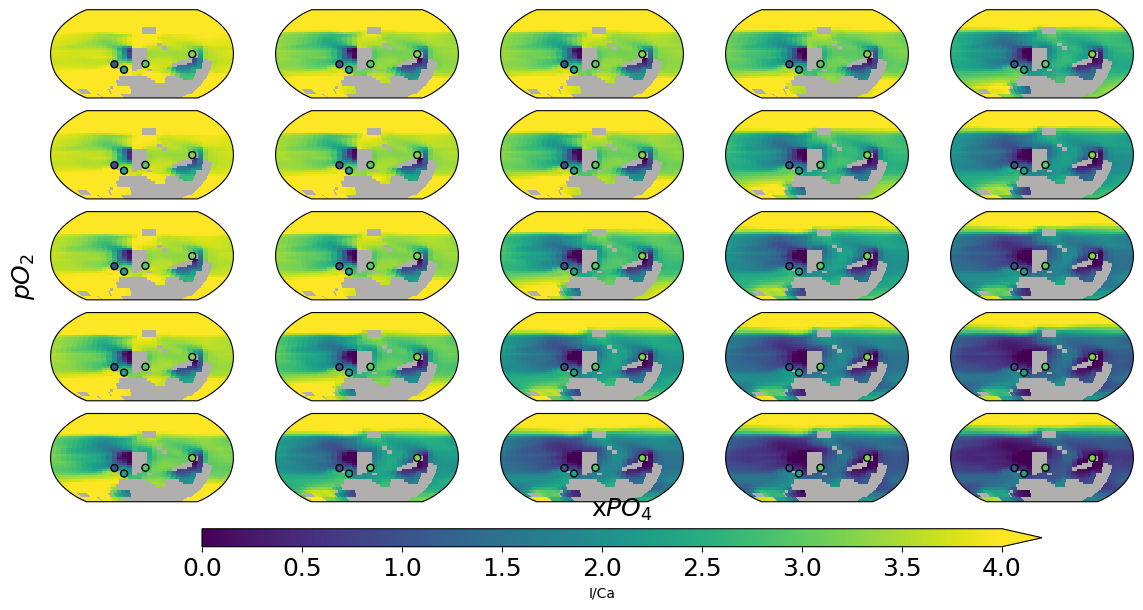

In [47]:
#Plot 2d mapview ensemble

fig = plt.figure(figsize=[12, 6]) #change second dimension depending on how spread outverticallyyou want the plots
#----------------------------------------------------------------------------------------------------
#subplots automaticaly set up to plot the 

#if you custom labels for each subplot define them here
#plots alphabet for the 
#labels =  [chr(i) for i in range(ord('a'), ord('z') + 1)] #this is to demonstrate how labeling subplots works using letters

#custom lables
#labels = 

#if you want to plot the m-score as the label run that section on Skill Metrics, uncomment and run this section
# mss1x = mss_values.reshape(-1, 5)
# mss1x = mss1x.astype(float)

# Convert mss1x values to strings with two decimal places
# mss_strings = np.array2string(mss1x, formatter={'float_kind': lambda x: f"{x:.2f}"})
# mss_strings = mss_strings.replace('[', '').replace(']', '').replace('\n', '').split()
#------------------------------------------------------------------------------------------------------

#details about color scheme/bar
#If you want colorbar to range up to maxvalue select this, otherwise define vmax below
max_value = np.nanmax([np.nanmax(content) for content in plot_me_3d['content']]) # only need this if plotting max value of all ensembles 

#colorbar recommended options, using fmap to not be confused by cmap above

#fmap = plt.get_cmap('viridis') # for IO3
#fmap = plt.get_cmap('RdBu') #for O2
#fmap = plt.get_cmap('Blues') 
#fmap = plt.get_cmap('BuPu') 
#fmap = plt.get_cmap('plasma') #for PO4
fmap = plt.get_cmap('viridis')#for I/Ca
#fmap = plt.get_cmap('RdYlBu_r') #use for SST
#fmap.set_under('grey') #sets the color under vmin to grey

#--------------------------------------------------------------------------------------------------------
#set the subplot grid a is y axis, b is x axis c is total 
#this makes a 5x5 grid
a = 5
b = 5
c = 25

#setting like this makes a horizontal 1 by 5 grid
#a = 1
#b = 5
#c = 5

cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03]) # this adjust positioning of the subplots within grid

#set up ordering of subplots 
#this plots ensembles 00 thru 04 on bottom row, horizontally it is in reverse order bc of how plt.suplotworks
subplot_order = [20,22,22,23,24,  15, 16,17,18,19,  10, 11, 12, 13, 14, 5,6, 7,8,9, 0,1,2,3,4]

#this plots a single line 
#subplot_order = [0,1,2,3,4]

subplot_kws = dict(projection=ccrs.Robinson(), facecolor='#b0afae')
#------------------------------------------------------------------------------------------------------
#plot the ensemble here


for i, index in enumerate(subplot_order):
    row = plot_me_2d.iloc[index] #to plot map view of a specific layer of the ocean change to plot_me_3d and make sure in def tracer 3d this line is selected->value = value[1,:,:]
    file_name = row['file']

    data_array = row['content']

    #ax = plt.subplot(1, 5, i+1, **subplot_kws) # select if only plotting horizontal line
    ax = plt.subplot(5, 5, i+1, **subplot_kws) # select if plotting a grid
    
    #change vmax= max_value or whatever makes sense for what you are plotting, vmax= 0.0003
    p = data_array.plot(x='lon', y='lat', vmin=0, vmax = 4, cmap=fmap, transform=ccrs.PlateCarree(), add_labels=False, add_colorbar=False, ax=ax)

    #subplot titles
    #ax.set_title(file_name, loc='left') # this plots the filenumber as the label
    #ax.set_title(labels[i], loc='center') # this plots your custom labels
    # ax.set_title(mss_strings[index], loc='center') # Use mss_strings with the original index

    #plot data overlay, if it is proxy data it is helpful to have the same vmin and vmax so it is colored the same, otherwise customize the way you want
    plt.scatter(x=sites[:, 0], y=sites[:, 1], c=sites[:,2], vmin=0, vmax=4, cmap=fmap, facecolor='none', edgecolor='black', marker='o', transform=ccrs.PlateCarree(), s=25)
   # plt.scatter(x = sites_SST[:,0], y = sites_SST[:,1], c = sites_SST[:,2], cmap = fmap, vmin = 0, vmax= 40,edgecolor = 'black', marker = 'o', transform=ccrs.PlateCarree(), s = 25)

plt.tight_layout(rect=[0, 0.1, 0.95, 0.97])
#plt.suptitle('10xpCO2 modern efolding 250107d',fontsize=16, x=0.5, y=0.98) #plot title

fig.text(0.5, 0.1, 'x$PO_4$', ha='center', fontsize=18) #xlabel
fig.text(-0.01, 0.5, '$pO_2$', va='center', rotation='vertical', fontsize=18) #ylabel

#colorbar finishing touches
cb = plt.colorbar(p, cax=cbar_ax, extend="max",  orientation='horizontal', label='I/Ca')#format='%.4f'#I/Ca $\\mu$mol/mol'
cb.ax.tick_params(labelsize=18) #change format .#f to get either more decimal places or e for scientific


#----------------
#plt.savefig('Figures/Ensembles/250109b/ICa_mapview.png', dpi=300, bbox_inches='tight')

plt.show()


Plot map view of 2d fields ensemble stored in plot_me_3d. Here O2 at 2nd vertical depth is plotted  


### Ensemble zonal profile

Plot ensemble of zonal or meridional depth profiles of plot_me_3d

In [ ]:
#this needs to be cleaned up

#cmap = plt.get_cmap('viridis')
#cmap.set_under('grey')

max_value = np.nanmax([np.nanmax(content) for content in plot_me_3d['content']])
#a = 5
#b = 5
#c = 25

a=1
b=5
c=5

#fmap = plt.get_cmap('viridis') # for IO2
fmap = plt.get_cmap('RdBu') #for O2
#fmap = plt.get_cmap('plasma') #for PO4
#fmap = plt.get_cmap('viridis')#for I/Ca
#fmap.set_under('grey')

subplot_kws = dict(facecolor='#b0afae') # Darker facecolor

fig = plt.figure(figsize=[12, 8])

fig.text(0.5, 0.1, 'PO4', ha='center', fontsize=18)
fig.text(-0.01, 0.5, 'pO2', va='center', rotation='vertical', fontsize=18)
#fig.text(0.5, 0.1, 'Inhibition [1xE-6] (mol/kg)(reduction)', ha='center', fontsize=18)
#fig.text(-0.01, 0.5, 'Lifetime (x 50 yrs) (oxidation)', va='center', rotation='vertical', fontsize=18)

# Create a single colorbar axes at the bottom
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # Adjust position and size as needed

for index, row in plot_me_3d.iterrows():
    file_name = row['file']
    data_array = row['content']


    zonal_depth=data_array.isel(lat=17)
    #data_array = np.ma.masked_where(grid_topo == 7, data_array)
    # Adjust subplot position for switching columns
    if c in [9, 6, 3]:  # Subplots that were in column 3
        subplot_index = c - 2
    elif c in [7, 4, 1]:  # Subplots that were in column 1
        subplot_index = c + 2
    else:
        subplot_index = c

    # Create a GeoAxes subplot within the loop
    ax = fig.add_subplot(a, b, subplot_index, **subplot_kws) # Pass subplot_kws
    new_zt = np.linspace(zonal_depth['zt'].min(), zonal_depth['zt'].max(), 150)
    new_lon = np.linspace(zonal_depth['lon'].min(), zonal_depth['lon'].max(), 150)

# Interpolate using xarray's `interp` method
    interpolated_zero = zonal_depth.interp(zt=new_zt, lon=new_lon, method='linear')
    ax = plt.subplot(5,5, c, **subplot_kws)
    p = interpolated_zero.plot(x='lon', y='zt',
                  vmin=0, #vmax=200E-6,
                  #vmax=0.0000005,
                  #vmax=max_value,
                  vmax=0.00030,
                  cmap = fmap,

                  ylim = (1000,0),
                  #add_colorbar=False,
                  add_labels=False,
                  add_colorbar=False,
                  ax=ax)              # Pass the GeoAxes object to the plot function


    ax.set_title(file_name,loc = 'left') # Set subplot title using 'file' column
    #ax.set_title(labels[index],loc = 'center')


    #p.axes.scatter(coordinates[:, 1], coordinates[:, 0], transform=ccrs.PlateCarree(), edgecolor = "black", color=color, alpha = 0.9, s=10)

# for plotting open circles
    #plt.scatter(x = ICa_long, y = ICa_lat, facecolor = 'none', edgecolor = 'black', marker = 'o', transform=ccrs.PlateCarree(), s = 50)
    c -= 1
    #plt.scatter(x = df_ICa_bkgd['%Long'], y = df_ICa_bkgd['z'], c = df_ICa_bkgd['I/Ca'], vmin= 0, vmax = 4, cmap = fmap, facecolor = 'none', edgecolor = 'black', marker = 'o', s = 50)
    #plt.scatter(x = df_ICa_KW['%Long'], y = df_ICa_KW['Lat '], c = df_ICa_KW['point'], vmin= 0, vmax = 4, cmap = fmap, facecolor = 'none', edgecolor = 'black', marker = 'o', transform=ccrs.PlateCarree(), s = 50)

plt.tight_layout(rect=[0, 0.1, 1, 0.97]) # Adjust layout to accommodate the colorbar
#plt.suptitle('Iodate depth profile at equator [1x modern Iodate inventory temp-dependent remineralization]', x = 0.5, y = 0.98)


# Add colorbar to the dedicated axes
cb = plt.colorbar(p, cax=cbar_ax, extend = "max", format='%.1e', orientation='horizontal', label = 'Iodate mol/mol')


plt.legend(['Bkg mean I/Ca'], loc = 'upper right')

cb.ax.tick_params(labelsize=18)
plt.show()

### Ensemble Latitudinal gradients

C:\Users\prowa\AppData\Local\Temp\ipykernel_20700\4227977049.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10", num_colors)  # Generate 'num_colors' distinct colors from 'tab10'


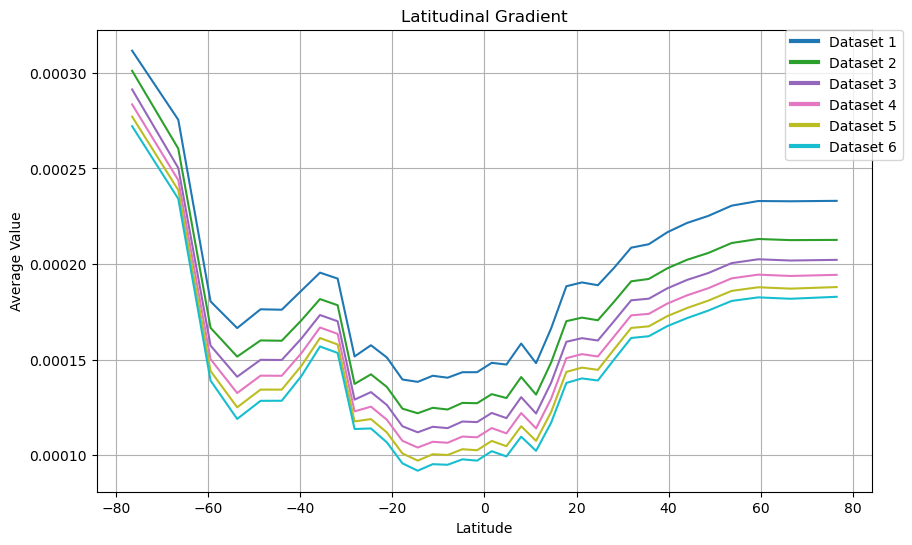

In [13]:
# Define custom colors
num_colors = len(plot_me_2d.content)  # Get the number of datasets
cmap = get_cmap("tab10", num_colors)  # Generate 'num_colors' distinct colors from 'tab10'
colors = [cmap(i) for i in range(num_colors)]  # Create a color list

# Define labels (adjust this based on your data)
labels = [f"Dataset {i+1}" for i in range(num_colors)]  

# Initialize plot
plt.figure(figsize=(10, 6))

# Get latitude values
lat = plot_me_2d.content[0]['lat']

# Loop through the dataset and plot each line
for i, x in enumerate(plot_me_2d.content):
    row_averages = x.mean(dim='lon')  # Average over longitude
    plt.plot(lat, row_averages, color=colors[i % len(colors)], label=labels[i])  # Assign colors and labels

# Add a grid
plt.grid(True)

# Create legend using custom Line2D objects
legend_lines = [Line2D([0], [0], color=c, linewidth=3, linestyle='-') for c in colors]
plt.legend(legend_lines, labels, loc='best', fontsize=10, bbox_to_anchor=(1.04, 1), borderaxespad=0)

# Set labels and title
plt.xlabel("Latitude")
plt.ylabel("Average Value")
plt.title("Latitudinal Gradient")

# Show plot
plt.show()


### Anomoly plots for ensembles

Plot the difference between one ensemble member and the others, or the difference between all sims in an ensemble from another single output. Here I map the difference in dissolved O2 at level z. 

In [101]:
# define default simulation you can to compare others to

# a single sim,save desirevd field into tracer_3d_map 

anom_compare = tracer_3d_map

#print(anom_compare)

# a sim from the same ensemble, save desired field into plot_me_3d

anom_compare_en = plot_me_3d.iloc[0]['content']# this will be correspond to 00 

anom_compare_en.values


array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.00018674, 0.00018737, 0.00018801, ..., 0.00018484, 0.00018548,
        0.00018611],
       [0.00018831, 0.00018895, 0.00018959, ..., 0.00018639, 0.00018703,
        0.00018767],
       [0.0001898 , 0.00019025, 0.0001907 , ..., 0.00018836, 0.00018886,
        0.00018933]], dtype=float32)

In [113]:
# Reference DataArray (baseline)
anom_compare = plot_me_3d.iloc[0]['content']

# Preallocate result array
anoms = np.empty(len(plot_me_3d))

for i in range(len(plot_me_3d)):
    # Extract current DataArray
    sim2 = plot_me_3d.iloc[i]['content']
    
    # Compute anomaly (difference field)
    diff = anom_compare.values - sim2.values
    print(diff)
    #anoms[i] = diff

anoms

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[          nan           nan           nan ...           nan
            nan           nan]
 [          nan           nan           nan ...           nan
            nan           nan]
 [          nan           nan           nan ...           nan
            nan           nan]
 ...
 [5.3919852e-05 5.4128031e-05 5.4306642e-05 ... 5.3134514e-05
  5.3420765e-05 5.3683456e-05]
 [5.3228679e-05 5.3389944e-05 5.3525277e-05 ... 5.2594041e-05
  5.2829244e-05 5.3041556e-05]
 [5.1287891e-05 5.1358002e-05 5.1400275e-05 ... 5.0857852e-05
  5.1032039e-05 5.1178882e-05]]
[[          nan           nan           nan ...           nan
            nan           nan]
 [          nan           nan           nan ...           nan
            nan           nan]
 [          nan           nan           nan ...           

array([0., 0., 0., 0., 0., 0.])

## Ensemble Time-Series

Plot time-series from an ensemble. For example if I want to plot a scatter plot of global SST vs benthic pO2 for an experiment of different radiative forcings (pCO2). 

In [35]:
# Extract Time-Series Data

def extract_final_values(file_path, column_name):
    results = []  # List to store extracted values

    for path_to_file in glob.glob(file_path):
        column_names = ["Time (yr)", "Temperature (C)", "_surT (ice-free) (C)", "_benT (C) [> 2000 m]", "_surT (C)"]
       # column_names = ["time (yr)", "global total O2 (mol)",  "global mean O2 (mol kg-1)", "surface (ice-free) O2 (mol kg-1)",  "benthic [> 2000 m] O2 (mol kg-1)",  "surface O2 (mol kg-1)"]
        try:
            series_SST = pd.read_csv(path_to_file, sep ='\s+', names=column_names, skiprows=1)
        except Exception as e:
            print(f"Error reading {path_to_file}: {e}")
            continue  # Skip this file and move to the next one
        
        # Extract the last row's value for the given column
        if column_name in series_SST.columns:
            final_value = series_SST.iloc[-1][column_name]
        else:
            print(f"Warning: Column '{column_name}' not found in {path_to_file}")
            final_value = None  # Assign None if the column is missing
        
        # Append the filename and final value to the results list
        results.append({"file": os.path.basename(path_to_file), column_name: final_value})

    # Convert list to a DataFrame
    df_result = pd.DataFrame(results)
    
    return df_result


#ignore the warning, it works

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
C:\Users\prowa\AppData\Local\Temp\ipykernel_45172\436111418.py:10: SyntaxWarning: invalid escape sequence '\s'
  series_SST = pd.read_csv(path_to_file, sep ='\s+', names=column_names, skiprows=1)


I want to plot the time series results of ensembles from serveral experiements as a scatter plot to see how changing one parameter (here orbital forcing) affects SST at different radiative forcings. To do this I want to save results of extract_final_value into a pickle file and retrieve that .pkl when I want to plot.

https://stackoverflow.com/questions/64367217/loading-and-plotting-multiple-pickle-file


In [37]:
# calculate global averages of tracers

glob_path = "D:/250109b/250109.pO2xPO4_5x5b.dat.*/biogem/biogem_series_ocn_temp.res"  #be sure to change this!


column_name = "_surT (C)"
#column_name = "global mean O2 (mol kg-1)"

SST_ensemble = extract_final_values(glob_path, column_name) # be sure to change the variable name for each set of data you want to save

SST_ensemble = SST_ensemble.round(2)
print(SST_ensemble)
#store your object as a pckle file

#with open('output.pkl', 'rb') as f:    
 #   list_from_pickle = pickle.load(f)
#print(list_from_pickle)

                          file  _surT (C)
0   biogem_series_ocn_temp.res      26.68
1   biogem_series_ocn_temp.res      26.68
2   biogem_series_ocn_temp.res      26.68
3   biogem_series_ocn_temp.res      26.68
4   biogem_series_ocn_temp.res      26.68
5   biogem_series_ocn_temp.res      26.68
6   biogem_series_ocn_temp.res      26.68
7   biogem_series_ocn_temp.res      26.68
8   biogem_series_ocn_temp.res      26.68
9   biogem_series_ocn_temp.res      26.68
10  biogem_series_ocn_temp.res      26.68
11  biogem_series_ocn_temp.res      26.68
12  biogem_series_ocn_temp.res      26.68
13  biogem_series_ocn_temp.res      26.68
14  biogem_series_ocn_temp.res      26.68
15  biogem_series_ocn_temp.res      26.68
16  biogem_series_ocn_temp.res      26.68
17  biogem_series_ocn_temp.res      26.68
18  biogem_series_ocn_temp.res      26.68
19  biogem_series_ocn_temp.res      26.68
20  biogem_series_ocn_temp.res      26.68
21  biogem_series_ocn_temp.res      26.68
22  biogem_series_ocn_temp.res    

# Skill Metrics & Statistics 


## Calculate M-scores and plot heatmap for ensemble

Important: plot_m2_2d needs to be the same as the proxy you are evaluating

Change the name of model_ICa to something more generic

**The first single netcdf file cell has to be run withthe same paleoconfiguration because this section uses site_coords and that is how it is calibrated to the paleoconfig**


In [49]:
# Extract simulated values at each site

#3d heatmap https://community.plotly.com/t/two-3d-surface-with-different-color-map/18931

#Calculating Mscore
#https://github.com/PeterRochford/SkillMetrics
#https://github.com/ruiying-ocean/cgeniepy
#https://github.com/ruiying-ocean/cgeniepy/blob/master/src/cgeniepy/skill.py
#https://journals.ametsoc.org/view/journals/clim/28/15/jcli-d-14-00702.1.xml

model_output = {}

for index, row in plot_me_2d.iterrows(): #save into plot_me_2d the field you want to perform statistical comparison to proxy data on
    x = row['content']
    #model_site = x.sel(lat=site_coords[:,1],lon=site_coords[:,0],method="nearest") 
    model_site = x.sel(lat=sites[:,1],lon=sites[:,0],method="nearest") 
    model_site = xr.DataArray.to_numpy(model_site)
    model_site = np.diag(model_site)
    model_output[index] = model_site 
#print(model_output)

Add a block of code here that explains what mscore is ...use math syntax

In [61]:
# Calculate M-Score

#subset the data values from proxy import section, this should work if you did or did not manually change the locations

proxy_ev_array = sites_KW[:,2]  # ev for event
proxy_bkg_array = sites[:,2]

#print(proxy_ev_array)

# Calculate the mean and variance of the proxy data 
v1 = proxy_ev_array.var()
v2 = proxy_bkg_array.var()

g1 = proxy_ev_array.mean()
g2 = proxy_bkg_array.mean()

#initialize calculate mscore
i = 0
mss_array={}

for row in model_output:
  #print(model_output)  
  #caluclate mean square error 

 #⭐ make sure to change this to either proxy_ev__array or proxy_bkg_array and that the below mscore is correctly chosen
  mse = np.square(np.subtract(model_output[i],proxy_ev_array)).mean()  

   #mean_squared_error(ICa_KW_array, model_ICa[i], squared =True)
  v3 = model_output[i].var()

  g3 = model_output[i].mean()

  #mscore = np.abs((2/np.pi)*np.arcsin(1-mse/(v2 + v3 + np.square(g3-g2)))) #bkg  
  mscore = np.abs((2/np.pi)*np.arcsin(1-mse/(v1 + v3 + np.square(g3-g1)))) # KW
  mss_array[i]=mscore
  #print(mscore)

  i=i+1

mss_values = np.array(list(mss_array.values()))
#print(mss_values)
mss1x = mss_values.reshape(-1, 5)# need to change final digit depending on ensemble size (e.g. 3 for a 3 by 3)
mss1x = mss1x.astype(float)
print(mss1x)

# you will yield an error like arcsin out of bounds if you do not use the correct array for mse and mscore combination

[[0.00385318 0.14140413 0.50444584 0.53510894 0.37111707]
 [0.0005779  0.00230695 0.15052792 0.51470343 0.55071419]
 [0.01227098 0.00167184 0.00821988 0.15660473 0.51407467]
 [0.0144713  0.00846649 0.00737123 0.01281834 0.1479249 ]
 [0.01539259 0.01239048 0.00236039 0.00641149 0.0098465 ]]


In [ ]:
#############################################################################
#If you want to plot the M-score as the subplot title this is where that is generated. 
#Rerun the cell that prints the ensemble map view with the mss_strings line uncommente

# Convert mss1x values to strings with two decimal places
mss_strings = np.array2string(mss1x, formatter={'float_kind': lambda x: f"{x:.2f}"})

# Remove brackets and extra characters
mss_strings = mss_strings.replace('[', '').replace(']', '').replace('\n', '').split()
###############################################################################

Setup to plot heatmap and save results. This first cell is also use to define the limits for benthic anoxia so if you don't want to plot mscore but want to plot benthic anoxia run this cell. This single cell is to maintain consistency when saving output to csv.

In [57]:
#set x and y labels for the heatmap
#a
#y = ['x0.8','x0.9', 'x1.0','x1.1','x1.2'] #O2
#x = ['x0.2','x0.3', 'x0.4','x0.5','x0.6'] #PO4

#b
y = ['x0.8','x0.9', 'x1.0','x1.1','x1.2']
x = ['x0.7','x0.8', 'x0.9','x1.0','x1.1']

#c
#y = ['x0.8','x0.9', 'x1.0','x1.1','x1.2'] #O2
#x = ['x1.2','x1.3', 'x1.4','x1.5','x1.6'] #PO4

#d
#y = ['x0.3','x0.4', 'x0.5','x0.6','x0.7'] #O2
#x = ['x0.7','x0.8', 'x0.9','x1.0','x1.1']

#e
#y = ['x0.3','x0.4', 'x0.5','x0.6','x0.7'] #O2
#x = ['x1.2','x1.3', 'x1.4','x1.5','x1.6'] #PO4

#f
#y = ['x0.3','x0.4', 'x0.5','x0.6','x0.7'] #O2
#x = ['x0.2','x0.3', 'x0.4','x0.5','x0.6'] #PO4

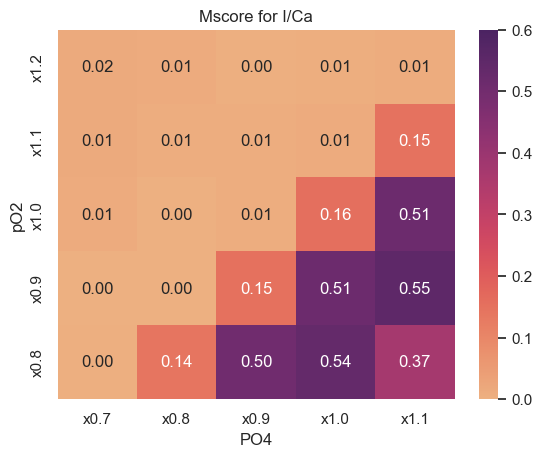

In [63]:
# plot heatmap
df_mss = pd.DataFrame(mss1x, columns = x, index = y)

df_mss = df_mss.sort_index(ascending=False)

#print(df_mss) # this prints the heat map as an array

sns.set()
ax=sns.heatmap(df_mss, cmap="flare", annot = True, fmt=".2f", vmin = 0,  vmax=0.6, label = 'Mscore')
ax.set(xlabel="PO4", ylabel="pO2")

plt.title("Mscore for I/Ca")
#plt.suptitle("KW")

#plt.savefig('Figures/Ensembles/250109b/pO2vsPO4_heatmap_kw.png', dpi=300, bbox_inches='tight')

plt.show()

## Save Results to datafile

Save mscore into csv file to be read in later. ** Make sure above heatmap looks *exactly* how you want it**

In [67]:
# make structured dataframe to save datato

columns = ['State', 'pCO2','pO2', 'PO4','mscore', 'efolding','benthic_anoxia', "globe_avg_temp"]

results = pd.DataFrame(columns = columns)

print(df_mss) #reshape df_mss so that y goes in PO4 column, x in pO2


df_mss_reset = df_mss.reset_index().rename(columns={'index': 'pO2'})
results = df_mss_reset.melt(id_vars='pO2', var_name='PO4', value_name='mscore')
results['mscore'] = results['mscore'].round(2)

#add additional information to columns
results['State'] = "Kellwasser"
results['pCO2'] = "10x"
results['efolding'] = 'x0.5'
results['globe_avg_temp'] = SST_ensemble['_surT (C)'] #from Ensemble Time-Series section

results['pO2'] = results['pO2'].str.lstrip('x').astype(float) #make pO2 and PO4 numerical
results['PO4'] = results['PO4'].str.lstrip('x').astype(float)

results



          x0.7      x0.8      x0.9      x1.0      x1.1
x1.2  0.014654  0.007055  0.119280  0.388308  0.502806
x1.1  0.012023  0.046442  0.293607  0.519195  0.370907
x1.0  0.033524  0.260430  0.529675  0.398763  0.261038
x0.9  0.217511  0.419032  0.425389  0.288029  0.151872
x0.8  0.401338  0.446676  0.302022  0.163074  0.076719


,pO2,PO4,mscore,State,pCO2,efolding,globe_avg_temp
0,1.2,0.7,0.01,Kellwasser,10x,x0.5,26.68
1,1.1,0.7,0.01,Kellwasser,10x,x0.5,26.68
2,1.0,0.7,0.03,Kellwasser,10x,x0.5,26.68
3,0.9,0.7,0.22,Kellwasser,10x,x0.5,26.68
4,0.8,0.7,0.40,Kellwasser,10x,x0.5,26.68
5,1.2,0.8,0.01,Kellwasser,10x,x0.5,26.68
6,1.1,0.8,0.05,Kellwasser,10x,x0.5,26.68
7,1.0,0.8,0.26,Kellwasser,10x,x0.5,26.68
8,0.9,0.8,0.42,Kellwasser,10x,x0.5,26.68
9,0.8,0.8,0.45,Kellwasser,10x,x0.5,26.68


In [363]:
# runfor first time save !!!!!!!!!

results.to_csv('Figures/Ensembles/250107b/results_250107b.csv')

#if permission denied close the file

In [285]:
# run to append, only run this if you do not need benthic anoxia, otherwise skip and run this line after 

results.to_csv('Ensembles/results.csv', mode='a', index=True, header=False)

## Taylor Diagrams

Calculate and Plot correlations of the proxy data points to the nearest grid point

In [ ]:
# 
std_obs = ICa_Bkg_array.std()
std_obs

ensemble_std = []
ensemble_corr = []

for x in range(len(model_ICa)):
  std = model_ICa[x].std()

  std_norm = std/std_obs


  corr = np.corrcoef(ICa_Bkg_array, model_ICa[x])
  corr = corr[0,1]
  ensemble_std.append(std_norm)
  ensemble_corr.append(std_norm)
  #print(std)
  #print(std_norm)
  #print(corr)

Important this package currently only plots in the first quadrant so you willwant to know if your coef are positive or negative by actualyl printing them. 

In [ ]:
# Create figure and Taylor Diagram instance
fig = plt.figure(figsize=(6, 6))
taylor = gv.TaylorDiagram(fig=fig, label='REF')
ax = plt.gca()

# Draw diagonal dashed lines from origin to correlation values
# Also enforces proper X-Y ratio
taylor.add_xgrid(np.array([0.6, 0.9]))

# Add model sets for p and t datasets
taylor.add_model_set(
    ensemble_std,
    ensemble_corr,
    fontsize= 10,  # specify font size
    xytext=(-3, 5),  # marker label location, in pixels
    color='red', # specify marker color
    marker='o', # specify marker shape
    facecolors='none', # specify marker fill
    s=50)  # marker size

# Add legend of ensemble names
#namearr = list(tas_rcp85.data_vars)
#taylor.add_model_name(namearr, fontsize=16)

# Add figure title
plt.title("Taylor Plot", size=26, pad=45)
taylor.add_contours(levels=np.arange(0, 1.1, 0.25),
                 colors='lightgrey',
                 linewidths=0.5)
#plt.show()

https://stackoverflow.com/questions/74503900/taylor-diagram-how-to-show-negative-correlation-python

Regression analysis: Plot predicted vs Actual and residual plots for model output vs observed proxy data

In [ ]:
#plot just one simulation with residual plot 


df_reg = pd.DataFrame({'Actual': ICa_Bkg_array.flatten(), 'Predicted': model_ICa[0].flatten()}) #if you want to plot just a single file replace Prdicted: data_2d

reg = LinearRegression().fit(df_reg[['Actual']], df_reg['Predicted'])
df_reg['Prediction_Line'] = reg.predict(df_reg[['Actual']])
score = reg.score(df_reg[['Actual']], df_reg['Predicted'])

coef = np.round(reg.coef_, 2)
# Create a 'hue' based on the actual values
df_reg['Hue'] = df_reg['Actual']

# Plot
plt.figure(figsize=(6, 4))
sns.set_theme(style = "ticks")
scatter = sns.scatterplot(data=df_reg, x='Actual', y='Predicted', hue='Hue', palette='viridis', alpha=0.8)

legend = scatter.legend_
legend.set_title(f"Coef = {coef} \n Actual Value" )

# Plot the regression line
plt.plot(df_reg['Actual'], df_reg['Prediction_Line'], color='red', label="Regression Line")
plt.plot([1,4], [1,4], 'k--')
plt.show()

In [ ]:
df_reg = pd.DataFrame({'Actual': ICa_Bkg_array.flatten(), 'Predicted': model_ICa[0].flatten()}) 

reg = LinearRegression().fit(df_reg[['Actual']], df_reg['Predicted'])
df_reg['Prediction_Line'] = reg.predict(df_reg[['Actual']])
score = reg.score(df_reg[['Actual']], df_reg['Predicted'])

coef = np.round(reg.coef_, 2)
# Create a 'hue' based on the actual values
df_reg['Hue'] = df_reg['Actual']

# Plot
plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
sns.set_theme(style = "ticks")
scatter = sns.scatterplot(data=df_reg, x='Actual', y='Predicted', hue='Hue', palette='viridis', alpha=0.8)
plt.suptitle("Proxy vs Simulated Regression")
plt.title("Actual vs Predicted")
legend = scatter.legend_
coef_value = reg.coef_.item()  # Extract scalar value
coef_str = f"{coef_value:.3f}"  # Format with 4 decimal places



# Update legend title
legend.set_title(f"Coef = {coef_str} \n Actual Value")
# Plot the regression line
plt.plot(df_reg['Actual'], df_reg['Prediction_Line'], color='red', label="Regression Line")
plt.plot([1,4], [1,4], 'k--')

plt.subplot(1,2,2)
sns.residplot(x = ICa_Bkg_array, y = model_ICa[0])
sns.move_legend(scatter, "upper left", bbox_to_anchor=(2.2, 1))
plt.title("Residuals")
plt.show()

## Plot Actual vs Predicted and residuals for ensemble. 


In [ ]:
# Number of models
num_models = len(model_output)

# Create subplots (2 columns: scatter plot & residuals)
fig, axes = plt.subplots(nrows=num_models, ncols=2, figsize=(12, 4 * num_models), sharex=True)

# Ensure axes is a 2D array (even if num_models == 1)
if num_models == 1:
    axes = np.array([axes])  # Convert to a 2D array with one row

sns.set_theme(style="ticks")

# Loop through each model and create plots
for n in range(num_models):
    ax_scatter, ax_resid = axes[n]  # Extract subplot axes for the current model

    df_reg = pd.DataFrame({
        #'Actual': ICa_Bkg_array.flatten(), # the coordinates of whatever you are doing stats on here I want I/Ca 
        'Actual': sites_SST[:,2].astype(float).flatten(),#here I want SST
        'Predicted': model_output[n].flatten()
    })

    # Perform Linear Regression
    reg = LinearRegression().fit(df_reg[['Actual']], df_reg['Predicted'])
    df_reg['Prediction_Line'] = reg.predict(df_reg[['Actual']])
    score = reg.score(df_reg[['Actual']], df_reg['Predicted'])
    coef = np.round(reg.coef_.item(), 4)  # Convert to scalar, round to 4 decimals

    # Sort values for smooth regression line
    df_reg.sort_values(by='Actual', inplace=True)

    # Create a 'hue' based on actual values
    df_reg['Hue'] = df_reg['Actual']

    # Scatter plot
    scatter = sns.scatterplot(data=df_reg, x='Actual', y='Predicted', hue='Hue', palette='viridis', alpha=0.8, ax=ax_scatter)

    # Adjust legend title
    legend = scatter.legend_
    legend.set_title(f"Coef = {coef} \n$R^2$ = {score:.2f} \n Model {n}")

    # Plot the regression line
    ax_scatter.plot(df_reg['Actual'], df_reg['Prediction_Line'], color='red', label="Regression Line")

    # Plot the 1:1 reference line dynamically
    min_val, max_val = df_reg['Actual'].min(), df_reg['Actual'].max()
    ax_scatter.plot([min_val, max_val], [min_val, max_val], 'k--', label="1:1 Line")

    ax_scatter.set_title(f"Model {n} - Actual vs Predicted")
    ax_scatter.legend()

    # Residual plot
    sns.residplot(data=df_reg, x='Actual', y='Predicted', ax=ax_resid, scatter_kws={"alpha": 0.8})
    ax_resid.set_title(f"Model {n} - Residual Plot")
    ax_resid.axhline(0, linestyle="--", color="black", linewidth=1)

plt.tight_layout()
#plt.show()


Stop here because there are new rules for the next part 

In [ ]:
assert False 

# Calculation of Tracer Areal/Volume Extents

## Extent of bottom water anoxia (or other tracer of your choice)

Calculate the percent of seafloor that is anoxic. 

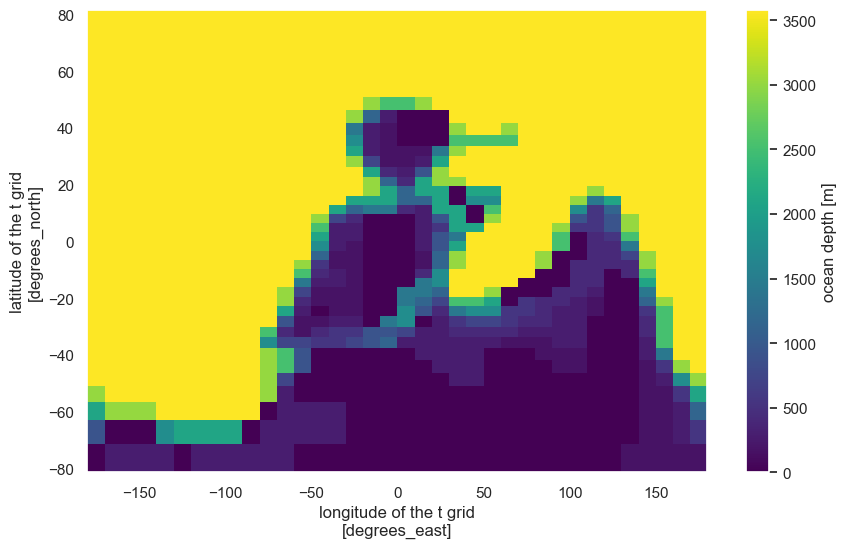

In [43]:
# Calc ocean floor area

#this cell defines the seafloor where the seafloor is from the topography and cell area saved in data_2d

grid_topo = data_2d['grid_topo']
grid_topo=grid_topo.fillna(0)
grid_topo.plot(x="lon")

ocn_floor=np.ma.masked_where(grid_topo == 0, grid_topo,copy = True)

#ocn_floor=np.ma.masked_where((grid_topo>174.75186) |(grid_topo == 0), grid_topo,copy = True)

#print(ocn_floor)

#ocn.plot(x="lon")
grid_area = data['grid_area']
#grid_area.plot(x="lon")

grid_area_ocn = np.ma.masked_where(ocn_floor.mask== True, grid_area,copy =True)
#print(ocn_floor)


In [45]:
#set the threshold for anoxia you want to calculate
anoxia_thres = 0
#anoxia_thres = 0.000006  # hypoxia threshold
#anoxia_thres = 0.0000072 # Ld50

<div class="alert-warning">
<b>Important</b> you must save the variable 'ocn_ben_O2' into plot_me_2d. Cross check that numbers you get for benthic anoxia are realistic with the 3-D ensemble map view 
</div>

In [51]:
# Calc benthic anoxic area from ensemble

benthic_anoxia = {}
for index, row in plot_me_2d.iterrows():
  b_O2 = row['content']
  #print(row['file'])  
    
  b_O2=b_O2.where(b_O2>0, )
  b_O2=b_O2.fillna(0)
    #print(b_O2_t)
  seafloor_anoxic_area = np.ma.masked_where(b_O2>anoxia_thres, grid_area_ocn,copy = True)
    #print(seafloor_anoxic_area)
  seafloor_anoxia_abs = np.ma.sum(seafloor_anoxic_area)
  seafloor_anoxia_per =seafloor_anoxia_abs/np.ma.sum(grid_area_ocn)*100

  benthic_anoxia[index]=seafloor_anoxia_per

sorted_dict = dict(benthic_anoxia.items())
#sorted_dict

df_anoxia = pd.DataFrame(sorted_dict.items(), columns=['file', '%anoxia'])
print(df_anoxia,3)

    file   %anoxia
0      0  2.925046
1      1  4.570384
2      2  7.221207
3      3  7.952468
4      4  9.323584
5      5  1.919561
6      6  3.016453
7      7  4.661792
8      8  7.221207
9      9  7.586838
10    10  1.462523
11    11  2.102377
12    12  3.473492
13    13  4.661792
14    14  7.129800
15    15  1.188300
16    16  1.645338
17    17  2.285192
18    18  3.656307
19    19  4.753199
20    20  0.822669
21    21  1.096892
22    22  1.828154
23    23  2.285192
24    24  3.564900 3


Save benthic anoxia into csv file. When doing really large ensembles can save value into csv file by appending ensemble and associaed value. This is saved linearly because later on it will be used to iteratively calculate the possible differences that fit a certain range, so be carfule when appending that you assign the correct ensemble # and you know what you assigned that #

I recomend commenting out the tocsv to avoid overwriting data

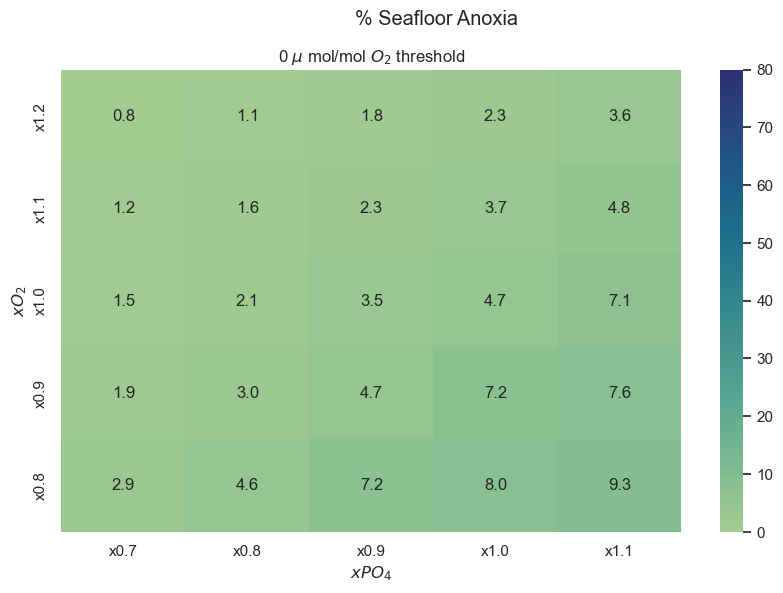

In [53]:
# Plot % benthic anoxia a heat map

anoxia = df_anoxia.to_numpy() #this seems really ineffcient but gets the job done
anoxia = np.reshape(anoxia[:,1],(-1,5))# need to change final digit depending on ensemble size
anoxia = anoxia.astype(float)

anoxia = pd.DataFrame(anoxia, columns=x, index=y) #these are the same x an y in the M-score calculation

# Sort for proper visualization
anoxia = anoxia.sort_index(ascending=False)

sns.set()
ax=sns.heatmap(anoxia, cmap="crest", annot = True, fmt=".1f",  vmin = 0,  vmax=80)
ax.set(xlabel="$xPO_4$", ylabel="$xO_2$")

plt.suptitle("% Seafloor Anoxia")
plt.title("0 $\\mu$ mol/mol $O_2$ threshold")

plt.show()

In [69]:
#print(anoxia)
anoxia = anoxia.round(2)
anoxia_reshape = anoxia.reset_index().rename(columns={'index': 'pO2'})
anoxia_reshape.fillna(0, inplace=True) # set nan to 0
anoxia_reshape = anoxia_reshape.melt(id_vars='pO2', var_name='PO4', value_name='ben_anoxia')

anoxia_reshape['pO2'] = anoxia_reshape['pO2'].str.lstrip('x').astype(float)
anoxia_reshape['PO4'] = anoxia_reshape['PO4'].str.lstrip('x').astype(float)

#print(anoxia_reshape)

results['ben_anoxia'] = anoxia_reshape['ben_anoxia']

results

,pO2,PO4,mscore,State,pCO2,efolding,globe_avg_temp,ben_anoxia
0,1.2,0.7,0.01,Kellwasser,10x,x0.5,26.68,0.82
1,1.1,0.7,0.01,Kellwasser,10x,x0.5,26.68,1.19
2,1.0,0.7,0.03,Kellwasser,10x,x0.5,26.68,1.46
3,0.9,0.7,0.22,Kellwasser,10x,x0.5,26.68,1.92
4,0.8,0.7,0.40,Kellwasser,10x,x0.5,26.68,2.93
5,1.2,0.8,0.01,Kellwasser,10x,x0.5,26.68,1.10
6,1.1,0.8,0.05,Kellwasser,10x,x0.5,26.68,1.65
7,1.0,0.8,0.26,Kellwasser,10x,x0.5,26.68,2.10
8,0.9,0.8,0.42,Kellwasser,10x,x0.5,26.68,3.02
9,0.8,0.8,0.45,Kellwasser,10x,x0.5,26.68,4.57


In [57]:
# save to results.csv

results.to_csv('Figures/Ensembles/250109b/results_250109b.csv')

# if Permission Denied it means the file is open, so close it

In [71]:
# run to append
results.to_csv('Figures/Ensembles/250109b/results_250109b.csv', mode='a', index=True, header=False)


## Global averages binned by latitude or depth

Plot average dissolved O2 for latitudinal bands (e.g., tropical, extratropical, temperate, polar regions). This may be helpful in recognizing where oxygen depletion is occuring between scenarios. This section is set up to process only one simulation at a time. If you have an ensemble you can subset each individually as demonstrated below and repeat.


<div>
<img src="depths.jpg" width="500"/>
</div>

zt values correspond to layer centers and for that reason the below calculationg is off ever so slightly (x10-5 digit) but really not enough to be a big deal.

<div>
<img src="zt_16_level.png" width="200"/>
</div>

In [61]:
# save each simulation of ensemble independently into new variable 

#O2_conc = plot_me_3d['content'][5] #set plot_me_3d to ocn_O2, and index which you want to calculate 

#single run

O2_conc = data_3d['ocn_O2']

In cGENIE shallow is the top most layer (zt = 1) and benthic/deep is >2000 m (zt = 12-16). This is what is printed out in the time series output files if you want to cross check. The code is correctly set up to calculate that below. However, if you want to say define Shallow as 0 to 228 m (epipelagic zone), Intermediate 228 to 1040 m (~thermocline), Deep 1040 to 4604 m then you can do that by changing the zt values ranges below.

In [55]:
shallow = np.array([1]) #zt values 
intermediate = np.array([2, 3, 4, 5,6,7,8,9,10,11])
deep = np.array([12,13,14,15, 16])


zts = O2_conc.zt.values #
print(O2_conc.zt.values)

dz = np.diff(zts) 
dz # thicknesses of each layer, notice how they increase with depth

[  40.42035469  127.55154304  228.77022554  346.35408824  482.94907667
  641.62893664  825.9643815  1040.10344261 1288.86481093 1577.84627023
 1913.55066185 2303.53221581 2756.5665407  3282.848098   3894.21960415
 4604.43852281]


array([ 87.13118835, 101.2186825 , 117.58386269, 136.59498844,
       158.67985997, 184.33544486, 214.13906111, 248.76136833,
       288.98145929, 335.70439163, 389.98155396, 453.03432489,
       526.28155729, 611.37150615, 710.21891866])

<div class="alert-warning">
<b>Important</b> that plot_me_3d has the indexing values[:,:,:] selected 
    if you get -> ValueError: Dimensions {'zt'} do not exist. Expected one or more of ('lat', 'lon')
</div>

In [63]:
#calculate global average, Single run

global_mean = O2_conc.mean()
print(f"the global average [O2] is {global_mean.values}")

#calculae global average between a range of depths 

shallow_mean = O2_conc.isel(zt = shallow-1).mean() #isel() selects by index starting at 0 so you need to subtract 1 
print(f"the shallow average [O2] is {shallow_mean.values}")

deep_mean = O2_conc.isel(zt = deep-1).mean() #isel() selects by index starting at 0 so you need to subtract 1 
print(f"the global deep water average [O2] is {deep_mean.values}")

intermediate = 3*global_mean.values - shallow_mean.values - deep_mean.values

print(f"the global intermediate deph average is [O2] is {intermediate}")

# these values should be similar to the time series output file for global, surface and benthic O2

the global average [O2] is 0.00014993303921073675
the shallow average [O2] is 0.00024215382291004062
the global deep water average [O2] is 0.00014416534395422786
the global intermediate deph average is [O2] is 6.347995076794177e-05


In [83]:
# calculate global average of tracer saved above at specific discrete depth

zt_values = [1, 5, 13]  # depths to calculate for, see plot above
average_o2_conc = {}
m= {}
for zt in zt_values:
  # Assuming zt corresponds to a depth index in the 'plot_me_3d' dataset.
  # Replace this if zt corresponds to a different dimension or variable
  try:
    o2_zt = O2_conc.isel(zt=zt-1)  
    average_o2 = o2_zt.mean().item()
    average_o2_conc[zt] = average_o2
    m = ['40 m', '482 m', '3282 m']
    #print(f"the average [O2] at depth {m} is ", average_o2_conc[zt])
  except KeyError:
    print(f"zt value {zt} not found in dataset.")
    average_o2_conc[zt] = None # Or handle the missing data differently
for i, txt in enumerate(m):
   print(f"the global average [O2] at depth {txt} is {average_o2_conc[zt_values[i]]:.6f}")


the global average [O2] at depth 40 m is 0.000203
the global average [O2] at depth 482 m is 0.000111
the global average [O2] at depth 3282 m is 0.000090


Calculate the latitudinal oxygen gradient for specific depths (not averaged over depth ranges). This as default calculates the average and plots a point per 20 degree band. If you want more or less points just change latitude_constraits. Right now only calculates for one 

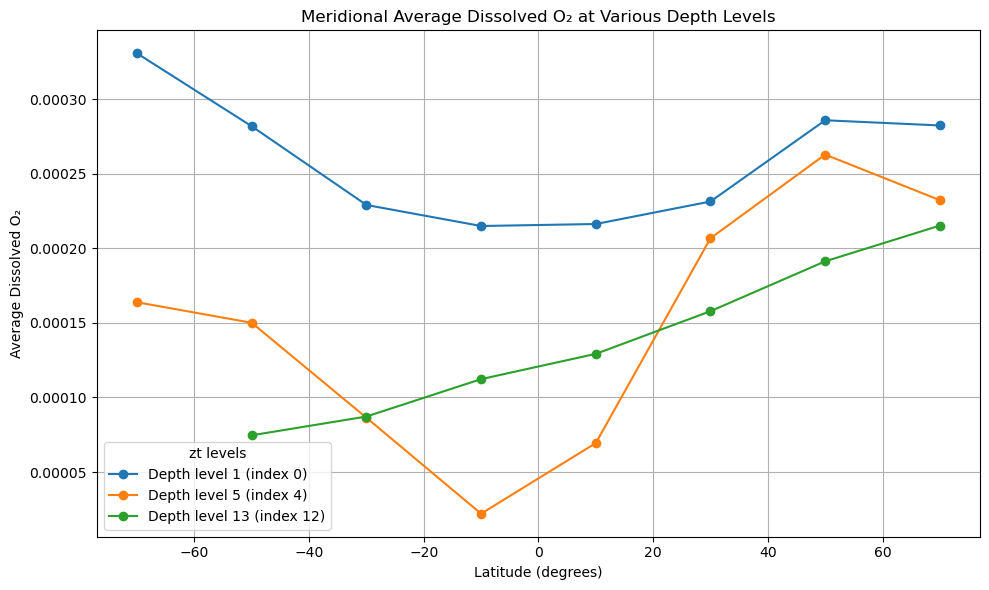

In [106]:
# modify this to plot two simulations and for zt to be zt = 1 to 3

#calculate dissolved oxygen by latitude at a specific depth
#zt_values = [1, 3, 5, 7, 9, 11, 13, 15]  # Choose the depth indices you want 
#zt_values = [1, 5, 13] # shallow, int, deep 

latitude_constraints = [(-80, -60), (-60, -40), (-40, -20), (-20, 0), 
                        (0, 20), (20, 40), (40, 60), (60, 80)]

plt.figure(figsize=(10, 6))
results_matrix = [] # assign space to store results in (outside loop so it can be saved to csv)

# Loop over each zt depth level
for zt in zt_values:
    lat_mids = []
    o2_averages = []
    
    for lat_min, lat_max in latitude_constraints:
        try:
            o2_zt = O2_conc.isel(zt=zt - 1) # because indexing starts at zero :=)
            o2_zt_constrained = o2_zt.where(
                (O2_conc.lat >= lat_min) & (O2_conc.lat <= lat_max),
                drop=True
            )
            average_o2 = o2_zt_constrained.mean().item() 

            lat_mids.append((lat_min + lat_max) / 2)
            o2_averages.append(average_o2)
           # print(f"The global average [O2] at zt index {zt-1} ({zt}th level) "       # if you want to print specific values 
           #   f"between {lat_min} and {lat_max} degrees latitude is: {average_o2:.7f}") # in lieu of me coding something to save as a csv ...
           
          
        
        except KeyError:
            print(f"zt value {zt} not found in dataset.")
        except AttributeError:
            print(f"Latitude variable not found in dataset or incorrect latitude range provided.")

          



    # Plot for this depth
    plt.plot(lat_mids, o2_averages, marker='o', label=f'Depth level {zt} (index {zt-1})')


# Final plot setup
plt.xlabel("Latitude (degrees)")
plt.ylabel("Average Dissolved O₂")
plt.title("Meridional Average Dissolved O₂ at Various Depth Levels")
plt.legend(title='zt levels')
plt.grid(True)
plt.tight_layout()

#plt.savefig('Figures/Scotese370Ma_O2grad.png', dpi=300, bbox_inches='tight')

#save data as csv
plt.show()


## Select me

In [187]:
shallow = [0,1,2,3] # top 350 m
bkg_O2 = bkg_3d['ocn_O2']
kw_O2 = kw_3d['ocn_O2']
#shallow_mean_O2 = bkg_O2.isel(time = 0, zt = shallow).mean() 
#shallow_mean_kw = kw_O2.isel(time = 0, zt = shallow).mean() 

bkg_mean= (
    bkg_O2.isel(time=-1, zt = shallow)               # final time slice
           .mean(dim=("lat", "lon", "zt"), skipna=True)
           .item()
)


kw_mean= (
    kw_O2.isel(time=-1, zt = shallow)               # final time slice
           .mean(dim=("lat", "lon", "zt"), skipna=True)
           .item()
)

print(bkg_mean)
print(kw_mean)

8.159947174135596e-05
7.622382690897211e-05


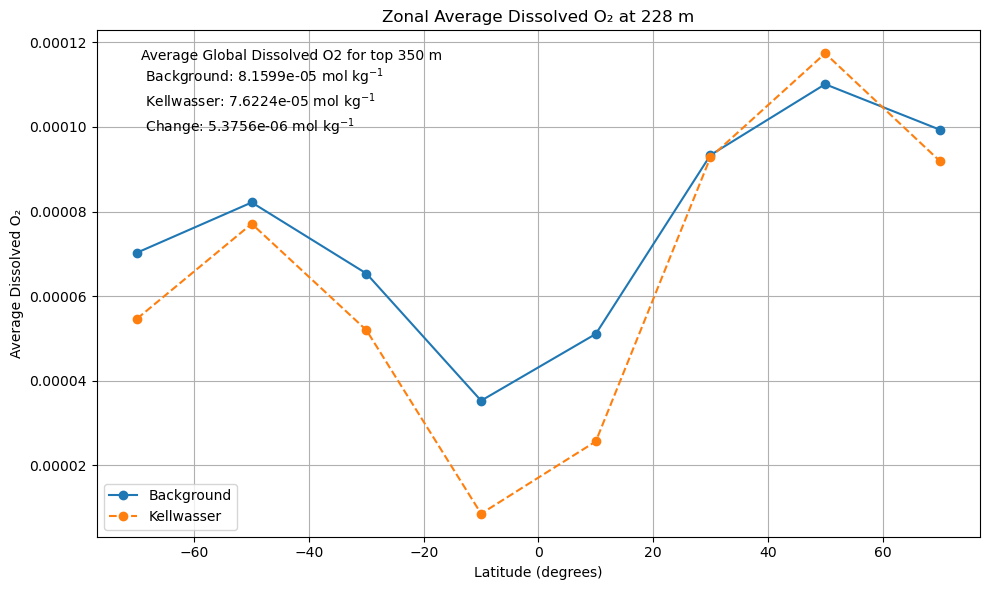

In [191]:
#calculate dissolved oxygen by latitude at a specific depth
zt = [0,1,2, 3]

shallow_mean_O2_bkg = bkg_O2.isel(time = 0, zt = zt).mean()
shallow_mean_O2_kw = kw_O2.isel(time = 0, zt = zt).mean()
O2_change = shallow_mean_O2_bkg - shallow_mean_O2_kw



zt_values = [2]  # Choose the depth indices you want 

latitude_constraints = [(-80, -60), (-60, -40), (-40, -20), (-20, 0), 
                        (0, 20), (20, 40), (40, 60), (60, 80)]

plt.figure(figsize=(10, 6))
results_matrix = [] # assign space to store results in (outside loop so it can be saved to csv)

# Loop over each zt depth level
for zt in zt_values:
    lat_mids = []
    o2_averages_bkg = []
    
    for lat_min, lat_max in latitude_constraints:
        try:
            o2_zt = bkg_O2.isel(zt=zt) # because indexing starts at zero :=)
            
            o2_zt_constrained = o2_zt.where(
                (bkg_O2.lat >= lat_min) & (bkg_O2.lat <= lat_max),
                drop=True
            )
            average_o2 = o2_zt_constrained.mean().item() 

            lat_mids.append((lat_min + lat_max) / 2)
            o2_averages_bkg.append(average_o2)
           # print(f"The global average [O2] at zt index {zt-1} ({zt}th level) "       # if you want to print specific values 
           #   f"between {lat_min} and {lat_max} degrees latitude is: {average_o2:.7f}") # in lieu of me coding something to save as a csv ...
           
        except KeyError:
            print(f"zt value {zt} not found in dataset.")
        except AttributeError:
            print(f"Latitude variable not found in dataset or incorrect latitude range provided.")

for zt in zt_values:
    lat_mids = []
    o2_averages_kw = []
    
    for lat_min, lat_max in latitude_constraints:
        try:
            o2_zt = kw_O2.isel(zt=zt) # because indexing starts at zero :=)
            o2_zt_constrained = o2_zt.where(
                (kw_O2.lat >= lat_min) & (kw_O2.lat <= lat_max),
                drop=True
            )
            average_o2_kw = o2_zt_constrained.mean().item() 

            lat_mids.append((lat_min + lat_max) / 2)
            o2_averages_kw.append(average_o2_kw)
           # print(f"The global average [O2] at zt index {zt-1} ({zt}th level) "       # if you want to print specific values 
           #   f"between {lat_min} and {lat_max} degrees latitude is: {average_o2:.7f}") # in lieu of me coding something to save as a csv ...
           
        except KeyError:
            print(f"zt value {zt} not found in dataset.")
        except AttributeError:
            print(f"Latitude variable not found in dataset or incorrect latitude range provided.")          



    # Plot for this depth
    plt.plot(lat_mids, o2_averages_bkg,  marker='o', label= "Background")
    plt.plot(lat_mids, o2_averages_kw, linestyle = "dashed", marker='o', label ="Kellwasser")

plt.text(
    0.05, 0.8, 
    f"Average Global Dissolved O2 for top 350 m \n Background: {shallow_mean_O2_bkg:.4e} mol kg$^{{-1}}$ \n Kellwasser: {shallow_mean_O2_kw:.4e} mol kg$^{{-1}}$ \n Change: {O2_change:.4e} mol kg$^{{-1}}$", 
    transform=plt.gca().transAxes
)

# Final plot setup
plt.xlabel("Latitude (degrees)")
plt.ylabel("Average Dissolved O₂")
plt.title(f"Zonal Average Dissolved O₂ at {int(bkg_O2.isel(zt=zt_values)['zt'].values)} m")

plt.legend(title='')
plt.grid(True)
plt.tight_layout()

plt.savefig(path_to_figs +"/Transitions/Transition 16/lat_dissolved_O2.png")

#save data as csv
plt.show()



In [78]:
# isolate basin (select lat, long box)
shallow_mean = O2_conc.isel(zt = shallow - 1).mean(dim=['time','zt']) # this maintains lat and long

# File Saving 

## Save to pdf

Save multiple different types plots or plots from different runs into a single pdf. For this you will want to run and save the plots you want into an object into Figure directory, assign the name to plot# in below code and run it. Change plot function to rearrange plots into desired order 

Plot on separate pages

In [623]:
pp = PdfPages('Figures/test.pdf')

plot1 ="Figures/Transitions/Transition 1/lat_dissolved_O2.png"
plot2 ="Figures/Transitions/Transition 1/O2_diff_plot.png"
plot3 ="Figures/Transitions/Transition 1/lat_sst.png"
plot4 ="Figures/Transitions/Transition 1/temp_diff_plot.png"

def function_plot(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 6))
    plt.axis('off')  # Turn off axes if you just want the image
    pp.savefig()
    plt.close()  # Close the figure to avoid overlap

# Save both images to the PDF
function_plot(plot1)
function_plot(plot2)
function_plot(plot3)

pp.close()

Plot on same pdf page. The difference is just where you define the figuresize and save it (outside of function). 

In [201]:
pp = PdfPages('Figures/Transitions/Transition 16/results.pdf')

plot1 ="Figures/Transitions/Transition 16/lat_dissolved_O2.png"
plot2 ="Figures/Transitions/Transition 16/O2_diff_plot.png"
plot3 ="Figures/Transitions/Transition 16/lat_sst.png"
plot4 ="Figures/Transitions/Transition 16/temp_diff_plot.png"

plt.figure(figsize=(10, 8))

def function_subplot(image_path, position):
    img = mpimg.imread(image_path)
    plt.subplot(2,2,position)
    plt.imshow(img)
    plt.axis('off')  # Turn off axes if you just want the image
    
    #plt.close()  # Close the figure to avoid overlap

# Save both images to the PDF

function_subplot(plot1, 1)
function_subplot(plot2, 2)
function_subplot(plot3, 3)
function_subplot(plot4, 4)

plt.tight_layout()
pp.savefig()
pp.close()
plt.close()

## Gifs

Make a gif of displaying different time slices or dataoverlay

In [104]:
# filepaths
fp_in = "Figures/GIFS/*.png" 
fp_out = "Figures/GIFS/ICa_mscore_movie.gif"

# use exit stack to automatically close opened images
with contextlib.ExitStack() as stack:

    # lazily load images
    imgs = (stack.enter_context(Image.open(f))
            for f in sorted(glob.glob(fp_in)))

    # extract  first image from iterator
    img = next(imgs)

    # https://pillow.readthedocs.io/en/stable/handbook/image-file-formats.html#gif
    img.save(fp=fp_out, format='GIF', append_images=imgs,
             save_all=True, duration=1000, loop=0) # duration is ms

## Future Updates

In [ ]:
#Improved readability 
from IPython.display import HTML, display
def set_background(color):    
    script = (
        "var cell = this.closest('.jp-CodeCell');"
        "var editor = cell.querySelector('.jp-Editor');"
        "editor.style.background='{}';"
        "this.parentNode.removeChild(this)"
    ).format(color)
    
    display(HTML('<img src onerror="{}" style="display:none">'.format(script)))
set_background('honeydew')

In [ ]:
'''def check_txt_file_header(file_path):
    try:
        with open(file_path, 'r') as file:
            first_line = file.readline().strip()
            
        print(f"First line of the file:\n{first_line}")
        
        is_header = input("Does this line represent a header? (yes/no): ").strip().lower()
        
        if is_header == 'yes':
            #print("The file has a header.")
            return True
        elif is_header == 'no':
            print("The file does not have a header.")
            return False
        else:
            print("Invalid input. Please respond with 'yes' or 'no'.")
            return check_txt_file_header(file_path)
    except FileNotFoundError:
        print("File not found. Please provide a valid file path.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage:
file_path = input("Enter the path to your .txt file: ").strip()
check_txt_file_header(file_path)

def process_file(file_path):
    if has_header:  # add else statement add header
               

            print("Processing file contents:") # make long, lat and I/Ca numeric andlabel character
            for line in file:
                
                print(line.strip())

def process_file(file_path):
    has_header = check_txt_file_header(file_path)

    try:
        with open(file_path, 'r+') as file:  # Open in read+write mode to modify file
            lines = file.readlines()
            
            if not has_header:
                # Add header if none exists
                header = "Long, Lat, I/Ca label\n"  # Example header; customize as needed
                lines.insert(0, header)
                print("No header found. Adding default header.")
                # Move back to the start and overwrite the file with the new header
                file.seek(0)
                file.writelines(lines)
            
            print("Processing file contents:")
            for line in lines:
                # Perform some operation on each line (e.g., print, parse, etc.)
                print(line.strip())

                